# 🛡️ Crypto Protocol Risk Scoring — Notebook 2 : Pipeline ML

**Objectif** : un **outil de ranking et de priorisation** de revue humaine. On attribue un score de vigilance à chaque protocole et on priorise les revues sur les protocoles avec le score le plus élevé.

> **Ce que le modèle fait** : il apprend le profil structurel des protocoles *historiquement ciblés* et attribue un score de vigilance à chaque protocole. Ce score permet de **prioriser les revues humaines** — les protocoles avec le score le plus élevé méritent une attention accrue.
>
> **Ce que le modèle ne fait pas** : il ne prédit pas si un protocole *va* être hacké. Les features sont des snapshots actuels, pas des données pré-hack. Cf. section Limites.

---

### Client fictif — Pour qui cet outil ?

> **DeFiGuard Capital** — fonds d'allocation de rendement DeFi, 12 personnes, 1 analyste
> sécurité à mi-temps. L'équipe doit screener ~500 protocoles pour décider des allocations
> trimestrielles, mais ne peut auditer manuellement que 30 protocoles par trimestre.
> Le `risk_score` s'insère en amont de la revue humaine : les 30 protocoles retenus
> sont ceux avec le score le plus élevé parmi les candidats — pas ceux que l'analyste
> connaît déjà.

**Périmètre** : protocoles DeFi, CEX, bridges — toute plateforme crypto financière documentée.  
**Prérequis** : avoir exécuté le Notebook 1 pour générer le fichier Parquet.

---

## Plan du notebook

| Section | Contenu |
|---------|--------|
| 0. Setup | Imports, configuration |
| 1. Chargement | Lecture du Parquet, aperçu initial |
| 2. EDA | Exploration visuelle des données |
| 3. Feature engineering | Nouvelles variables dérivées |
| 4. Preprocessing | Pipeline sklearn, split train/val/test (groupé par protocole) |
| 5. Déséquilibre de classes | class_weight, comparaison LR vs RF |
| 6. Modèles | Logistic Regression, Random Forest, XGBoost |
| 7. Métriques | Accuracy, Confusion Matrix, ROC-AUC, Precision-Recall |
| 8. Threshold tuning | Ajustement du seuil de décision (référence) |
| 9. Interprétabilité | Feature importance, SHAP values |
| 10. Risk Score | Ranking protocol-level, Recall@k, Lift@k |
| 11. Aller plus loin | GNN, anomaly detection (conceptuel) |

## 0. Setup

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

# Sklearn — preprocessing
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import RobustScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

# Sklearn — modèles
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier

# Sklearn — métriques
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, precision_recall_curve,
    ConfusionMatrixDisplay, average_precision_score
)

# XGBoost
from xgboost import XGBClassifier

# SHAP
import shap

# Configuration
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:.4f}')
sns.set_style('whitegrid')
RANDOM_STATE = 42

print('✅ Imports OK')

✅ Imports OK


## 1. Chargement et exploration initiale

In [35]:
# Chargement du dataset
# Parquet préserve les types — pas de conversion surprise comme avec CSV
df_raw = pd.read_parquet('data/df_defi_risk.parquet')

print(f'Dataset chargé : {df_raw.shape[0]} protocoles × {df_raw.shape[1]} features')
print(f'Incidents hackés retenus dans la base modélisée : {int(df_raw["hacked"].sum())}')
print("Population modélisée : protocoles DefiLlama encore actifs avec TVL > 0 et date valide.")
print("→ Ce notebook ne modélise donc pas tous les hacks historiques documentés,")
print("  mais le risque au sein de cette base active filtrée construite dans le Notebook 1.")
df_raw.head()

Dataset chargé : 4883 protocoles × 19 features
Incidents hackés retenus dans la base modélisée : 164
Population modélisée : protocoles DefiLlama encore actifs avec TVL > 0 et date valide.
→ Ce notebook ne modélise donc pas tous les hacks historiques documentés,
  mais le risque au sein de cette base active filtrée construite dans le Notebook 1.


,protocol,tvl,log_tvl,age_days,tvl_per_day,audit_count,chain_count,has_audit,is_multichain,is_dex,is_lending,is_bridge,bridgeHack,audit_status,category,technique,loss_usd,hack_date,hacked
0,Binance CEX,157300895087.8120,25.7814,1221.0000,128724136.7331,0,32,False,1,0,0,0,False,Unaudited,CEX,NaN,NaN,NaT,0
1,Aave V3,26226310322.4022,23.9900,1446.0000,18124609.7598,1,20,True,1,0,1,0,False,Audited,Lending,CAPO Oracle Misconfiguration,27780000.0000,2026-03-12,1
2,OKX,18899856856.6687,23.6624,1221.0000,15466331.3066,0,19,False,1,0,0,0,False,Unaudited,CEX,NaN,NaN,NaT,0
3,Bitfinex,17577249303.0114,23.5899,1221.0000,14384001.0663,0,20,False,1,0,0,0,False,Unaudited,CEX,NaN,NaN,NaT,0
4,Bybit,16323251209.7666,23.5159,1217.0000,13401684.0803,0,35,False,1,0,0,0,False,Unaudited,CEX,Safe Multisig wallet Phishing Exploit,1400000000.0000,2025-02-21,1


In [36]:
# Structure du dataset : types de colonnes et couverture des données

# Types groupés
print('Types de données :')
for dtype, group in df_raw.dtypes.astype(str).groupby(df_raw.dtypes.astype(str)):
    print(f'  {str(dtype):<15} : {list(group.index)}')

# Valeurs manquantes en %
missing_pct = (df_raw.isnull().sum() / len(df_raw) * 100)
missing_pct = missing_pct[missing_pct > 0].sort_values(ascending=False)
hack_only_cols = ['technique', 'loss_usd', 'hack_date']

print(f'\nValeurs manquantes ({len(missing_pct)} colonne(s) concernée(s)) :')
for col, pct in missing_pct.items():
    n = df_raw[col].isnull().sum()
    tag = '← hack-only' if col in hack_only_cols else ''
    print(f'  {col:<25} {pct:5.1f}%  ({n}/{len(df_raw)})  {tag}')

n_complete = (df_raw.isnull().sum() == 0).sum()
hack_rate  = df_raw['hacked'].mean()
print(f'\n{n_complete}/{len(df_raw.columns)} colonnes sans aucune valeur manquante')
print(f'\nNote : les colonnes "hack-only" ({len(hack_only_cols)}) ne sont renseignées que')
print(f'pour les protocoles hackés ({hack_rate:.1%} du dataset) — 96.7% manquant est attendu.')
print(f'Ces colonnes décrivent CE QUI S\'EST PASSÉ après le hack (technique, pertes...),')
print(f'pas des signaux prédictifs → elles seront exclues des features du modèle.')


Types de données :
  bool            : ['has_audit', 'bridgeHack']
  datetime64[ms]  : ['hack_date']
  float64         : ['tvl', 'log_tvl', 'age_days', 'tvl_per_day', 'loss_usd']
  int64           : ['audit_count', 'chain_count', 'is_multichain', 'is_dex', 'is_lending', 'is_bridge', 'hacked']
  str             : ['protocol', 'audit_status', 'category', 'technique']

Valeurs manquantes (3 colonne(s) concernée(s)) :
  technique                  96.7%  (4724/4883)  ← hack-only
  loss_usd                   96.6%  (4719/4883)  ← hack-only
  hack_date                  96.6%  (4719/4883)  ← hack-only

16/19 colonnes sans aucune valeur manquante

Note : les colonnes "hack-only" (3) ne sont renseignées que
pour les protocoles hackés (3.4% du dataset) — 96.7% manquant est attendu.
Ces colonnes décrivent CE QUI S'EST PASSÉ après le hack (technique, pertes...),
pas des signaux prédictifs → elles seront exclues des features du modèle.


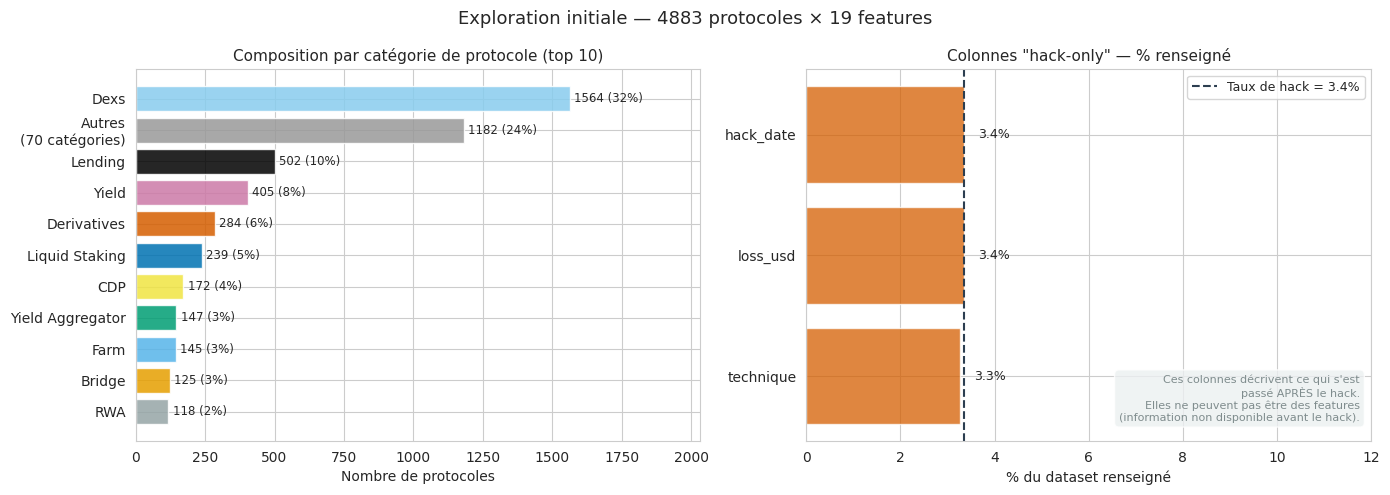

→ 80 catégories de protocoles au total. Top : Dexs (32%).
  La diversité des catégories sera encodée (One-Hot) lors du preprocessing.
→ Les 3 colonnes "hack-only" (technique、loss_usd、hack_date)
  sont renseignées à ~3.3% — aligné avec le taux de hack (3.4%).
  Elles seront exclues des features : information post-hack, non disponible en prédiction réelle.

→ Distribution de la variable cible et déséquilibre des classes : voir section 2.1.


In [37]:
# Vue d'ensemble de la composition du dataset
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Panel 1 : Répartition par catégorie (top 10 + Autres) ---
cat_counts_full = df_raw['category'].value_counts()
top10 = cat_counts_full.head(10)
n_autres = cat_counts_full.iloc[10:].sum()
n_cat_autres = len(cat_counts_full) - 10
cat_plot = pd.concat([top10, pd.Series({'Autres\n(' + str(n_cat_autres) + ' catégories)': n_autres})])
cat_plot = cat_plot.sort_values()

# Palette Okabe-Ito (colorblind-safe, WCAG 2.1 §1.4.1)
OKABE_ITO = ['#E69F00','#56B4E9','#009E73','#F0E442','#0072B2','#D55E00','#CC79A7','#000000','#999999','#88CCEE']
colors_cat = ['#95a5a6'] + [OKABE_ITO[i % len(OKABE_ITO)] for i in range(len(top10))]
bars = axes[0].barh(cat_plot.index, cat_plot.values, color=colors_cat, edgecolor='white', alpha=0.85)
for bar, val in zip(bars, cat_plot.values):
    axes[0].text(val + 15, bar.get_y() + bar.get_height()/2,
                 f'{val} ({val/len(df_raw):.0%})', va='center', fontsize=8.5)
axes[0].set_title('Composition par catégorie de protocole (top 10)', fontsize=11)
axes[0].set_xlabel('Nombre de protocoles')
axes[0].set_xlim(0, cat_plot.max() * 1.3)

# --- Panel 2 : Colonnes hack-only — % renseigné ---
hack_only_cols = ['technique', 'loss_usd', 'hack_date']
fill_pct = (df_raw[hack_only_cols].notna().sum() / len(df_raw) * 100).sort_values()

bars2 = axes[1].barh(fill_pct.index, fill_pct.values, color='#D55E00', alpha=0.75, edgecolor='white')
axes[1].axvline(df_raw['hacked'].mean() * 100, color='#2c3e50', linewidth=1.5,
                linestyle='--', label=f"Taux de hack = {df_raw['hacked'].mean():.1%}")
for bar, val in zip(bars2, fill_pct.values):
    axes[1].text(val + 0.3, bar.get_y() + bar.get_height()/2,
                 f'{val:.1f}%', va='center', fontsize=9)
axes[1].set_title('Colonnes "hack-only" — % renseigné', fontsize=11)
axes[1].set_xlabel('% du dataset renseigné')
axes[1].set_xlim(0, 12)
axes[1].legend(fontsize=9)
axes[1].text(0.98, 0.05,
             'Ces colonnes décrivent ce qui s\'est\npassé APRÈS le hack.\nElles ne peuvent pas être des features\n(information non disponible avant le hack).',
             transform=axes[1].transAxes, ha='right', va='bottom',
             fontsize=8, color='#7f8c8d',
             bbox=dict(boxstyle='round,pad=0.4', facecolor='#ecf0f1', alpha=0.8))

fig.suptitle(f'Exploration initiale — {len(df_raw)} protocoles × {len(df_raw.columns)} features', fontsize=13)
plt.tight_layout()
plt.show()

# Observations
top_cat  = cat_counts_full.index[0]
top_pct  = cat_counts_full.iloc[0] / len(df_raw)
n_cat    = len(cat_counts_full)
print(f'→ {n_cat} catégories de protocoles au total. Top : {top_cat} ({top_pct:.0%}).')
print(f'  La diversité des catégories sera encodée (One-Hot) lors du preprocessing.')
print(f'→ Les {len(hack_only_cols)} colonnes "hack-only" ({"、".join(hack_only_cols)})')
print(f'  sont renseignées à ~{fill_pct.mean():.1f}% — aligné avec le taux de hack ({df_raw["hacked"].mean():.1%}).')
print(f'  Elles seront exclues des features : information post-hack, non disponible en prédiction réelle.')
print(f'\n→ Distribution de la variable cible et déséquilibre des classes : voir section 2.1.')


## 2. EDA — Explorer les données avant de modéliser

> **Règle d'or** : on ne touche jamais au modèle avant d'avoir compris les données.  
> Une EDA rigoureuse évite les biais et les mauvaises surprises à l'entraînement.

### 2.1 Distribution de la variable cible

> **Accessibilité** : les palettes de ce notebook suivent la palette Okabe-Ito (colorblind-safe)
> conformément aux critères WCAG 2.1 §1.4.1 (distinction des éléments non basée uniquement sur la couleur).

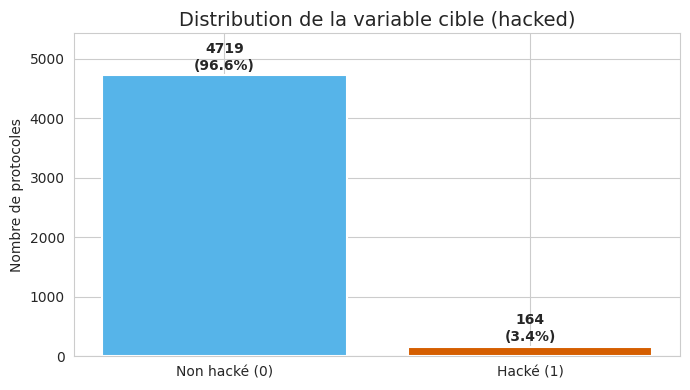

⚠️ Fort déséquilibre de classes : 3.4% de protocoles hackés (164 sur 4883).
→ Un modèle naïf qui prédit "safe" pour tout le monde aurait déjà 96.6% d'accuracy — sans rien apprendre !
→ Ce déséquilibre est au cœur de la Section 5 : class_weight, comparaison LR vs RF, threshold tuning.


In [38]:
fig, ax = plt.subplots(figsize=(7, 4))

counts = df_raw['hacked'].value_counts().sort_index()
colors = ['#56B4E9', '#D55E00']  # Okabe-Ito : bleu ciel / orange-rouge
bars = ax.bar(['Non hacké (0)', 'Hacké (1)'], counts.values, color=colors, edgecolor='white', linewidth=1.5)

# Annoter les barres avec le pourcentage
total = counts.sum()
for bar, count in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + total*0.01,
            f'{count}\n({count/total:.1%})', ha='center', va='bottom', fontweight='bold')

ax.set_title('Distribution de la variable cible (hacked)', fontsize=14)
ax.set_ylabel('Nombre de protocoles')
ax.set_ylim(0, counts.max() * 1.15)
plt.tight_layout()
plt.show()

ratio_hacked = df_raw['hacked'].mean()
n_hacked = int(df_raw['hacked'].sum())
print(f'⚠️ Fort déséquilibre de classes : {ratio_hacked:.1%} de protocoles hackés ({n_hacked} sur {len(df_raw)}).')
print(f'→ Un modèle naïf qui prédit "safe" pour tout le monde aurait déjà {1-ratio_hacked:.1%} d\'accuracy — sans rien apprendre !')
print('→ Ce déséquilibre est au cœur de la Section 5 : class_weight, comparaison LR vs RF, threshold tuning.')

### 2.2 Distribution des features numériques

On visualise les distributions des features clés pour détecter les asymétries et décider des transformations nécessaires avant la modélisation.

**Transformation logarithmique** — pour les features très asymétriques (comme le TVL), on applique :

```python
log_tvl = np.log1p(tvl)   # = log(tvl + 1)
```

- **`log`** : le logarithme compresse les grandes valeurs et étire les petites — un protocole à 1 Md$ ne vaut plus 1 000 000× plus qu'un à 1 000$, mais ~3× en log
- **`+ 1`** : `np.log1p(x)` calcule `log(x + 1)` — protège contre `log(0)` pour les protocoles avec TVL nul
- **Le résultat est sans unité** (adimensionnel) : X affiche `log(TVL + 1)`
- **Le nom `log_tvl`** reflète directement la transformation : logarithme du TVL


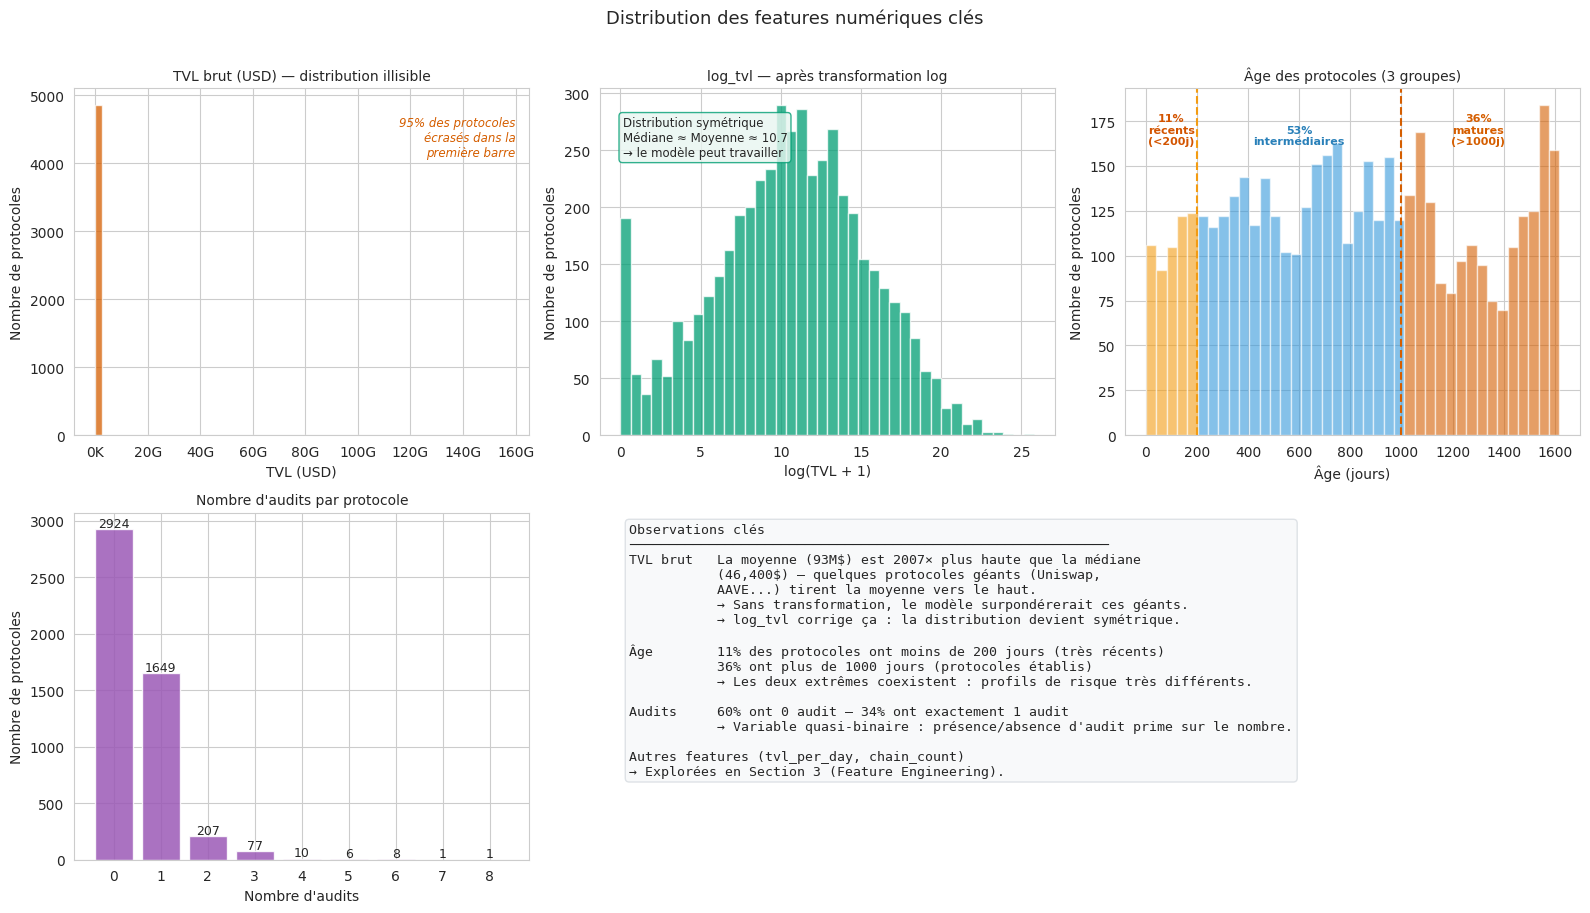

In [39]:
# 3 graphes ciblés : tvl brut vs log (démonstration transformation), âge, audit
fig = plt.figure(figsize=(16, 9))

# ── Panel 1 : TVL brut — montre le PROBLÈME ──────────────────────────────────
ax1 = fig.add_subplot(2, 3, 1)
data_tvl = df_raw['tvl'].dropna()
ax1.hist(data_tvl, bins=60, color='#D55E00', alpha=0.75, edgecolor='white')
ax1.set_title('TVL brut (USD) — distribution illisible', fontsize=10)
ax1.set_xlabel('TVL (USD)')
ax1.set_ylabel('Nombre de protocoles')
ax1.xaxis.set_major_formatter(plt.FuncFormatter(
    lambda x, _: f'{x/1e9:.0f}G' if x >= 1e9 else (f'{x/1e6:.0f}M' if x >= 1e6 else f'{x/1e3:.0f}K')))
p95_tvl = data_tvl.quantile(0.95)
n_compressed = (data_tvl < p95_tvl).mean()
ax1.text(0.97, 0.92,
         f'{n_compressed:.0%} des protocoles\nécrasés dans la\npremière barre',
         transform=ax1.transAxes, ha='right', va='top', fontsize=8.5,
         color='#D55E00', style='italic')

# ── Panel 2 : log_tvl — montre la SOLUTION ───────────────────────────────────
ax2 = fig.add_subplot(2, 3, 2)
data_log = df_raw['log_tvl'].dropna()
ax2.hist(data_log, bins=40, color='#009E73', alpha=0.75, edgecolor='white')
ax2.set_title('log_tvl — après transformation log', fontsize=10)
ax2.set_xlabel('log(TVL + 1)')
ax2.set_ylabel('Nombre de protocoles')
med_log = data_log.median()
ax2.text(0.05, 0.92,
         f'Distribution symétrique\nMédiane ≈ Moyenne ≈ {med_log:.1f}\n→ le modèle peut travailler',
         transform=ax2.transAxes, ha='left', va='top', fontsize=8.5,
         bbox=dict(boxstyle='round', facecolor='#e8f5f0', edgecolor='#009E73', alpha=0.8))

# ── Panel 3 : age_days — 3 groupes annotés ────────────────────────────────────
ax3 = fig.add_subplot(2, 3, 3)
data_age = df_raw['age_days'].dropna()
n, bins, patches = ax3.hist(data_age, bins=40, color='#3498db', alpha=0.6, edgecolor='white')

# Colorer et annoter les 3 zones
for patch, b in zip(patches, bins[:-1]):
    if b < 200:
        patch.set_facecolor('#f39c12')
    elif b > 1000:
        patch.set_facecolor('#D55E00')

ax3.axvline(200,  color='#f39c12', linestyle='--', linewidth=1.5)
ax3.axvline(1000, color='#D55E00', linestyle='--', linewidth=1.5)

p_recent = (data_age < 200).mean()
p_mid    = ((data_age >= 200) & (data_age <= 1000)).mean()
p_mature = (data_age > 1000).mean()
ymax = n.max()
ax3.text(100,  ymax * 0.88, f'{p_recent:.0%}\nrécents\n(<200j)', ha='center', fontsize=8, color='#d35400', fontweight='bold')
ax3.text(600,  ymax * 0.88, f'{p_mid:.0%}\nintermédiaires', ha='center', fontsize=8, color='#2980b9', fontweight='bold')
ax3.text(1300, ymax * 0.88, f'{p_mature:.0%}\nmatures\n(>1000j)', ha='center', fontsize=8, color='#D55E00', fontweight='bold')

ax3.set_title('Âge des protocoles (3 groupes)', fontsize=10)
ax3.set_xlabel('Âge (jours)')
ax3.set_ylabel('Nombre de protocoles')

# ── Panel 4 : audit_count discret ─────────────────────────────────────────────
ax4 = fig.add_subplot(2, 3, 4)
audit_vc = df_raw['audit_count'].value_counts().sort_index()
ax4.bar(audit_vc.index.astype(str), audit_vc.values,
        color='#9b59b6', edgecolor='white', alpha=0.85)
ax4.set_title("Nombre d'audits par protocole", fontsize=10)
ax4.set_xlabel("Nombre d'audits")
ax4.set_ylabel('Nombre de protocoles')
for i, v in enumerate(audit_vc.values):
    ax4.text(i, v + 20, str(v), ha='center', fontsize=9)

# ── Panels 5-6 : annotations pédagogiques ────────────────────────────────────
ax5 = fig.add_subplot(2, 3, (5, 6))
ax5.axis('off')

p_0audit = (df_raw['audit_count'] == 0).mean()
p_1audit = (df_raw['audit_count'] == 1).mean()
ratio_moy = df_raw['tvl'].mean() / df_raw['tvl'].median()

summary = (
    f"Observations clés\n"
    f"{'─'*60}\n"
    f"TVL brut   La moyenne ({df_raw['tvl'].mean()/1e6:.0f}M$) est {ratio_moy:.0f}× plus haute que la médiane\n"
    f"           ({df_raw['tvl'].median():,.0f}$) — quelques protocoles géants (Uniswap,\n"
    f"           AAVE...) tirent la moyenne vers le haut.\n"
    f"           → Sans transformation, le modèle surpondérerait ces géants.\n"
    f"           → log_tvl corrige ça : la distribution devient symétrique.\n\n"
    f"Âge        {p_recent:.0%} des protocoles ont moins de 200 jours (très récents)\n"
    f"           {p_mature:.0%} ont plus de 1000 jours (protocoles établis)\n"
    f"           → Les deux extrêmes coexistent : profils de risque très différents.\n\n"
    f"Audits     {p_0audit:.0%} ont 0 audit — {p_1audit:.0%} ont exactement 1 audit\n"
    f"           → Variable quasi-binaire : présence/absence d\'audit prime sur le nombre.\n\n"
    f"Autres features (tvl_per_day, chain_count)\n"
    f"→ Explorées en Section 3 (Feature Engineering)."
)
ax5.text(0.03, 0.97, summary, transform=ax5.transAxes,
         va='top', ha='left', fontsize=9.5, family='monospace',
         bbox=dict(boxstyle='round', facecolor='#f8f9fa', edgecolor='#dee2e6'))

fig.suptitle('Distribution des features numériques clés', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


### 2.3 Comparaison des features par classe — Hackés vs Non hackés

> **But** : vérifier si la valeur typique d'une feature diffère entre protocoles hackés et sains.

Quatre visualisations adaptées à chaque type de variable :
- **TVL et Âge** → *box plot* : médiane (trait central), Q1–Q3 (boîte), valeurs extrêmes (moustaches).
  Si les boîtes **se décalent** → signal potentiel. Si elles **se superposent** → feature peu discriminante seule.
- **Audit count** → *taux de hack par groupe* (0 / 1 / 2+ audits) superposé au TVL médian.
  Permet de voir si le niveau d'audit protège réellement et d'identifier un éventuel effet confondant.
- **Category** → *taux de hack par catégorie de protocole* (bar chart horizontal trié).
  La catégorie est la feature catégorielle la plus discriminante — certaines catégories concentrent le risque.


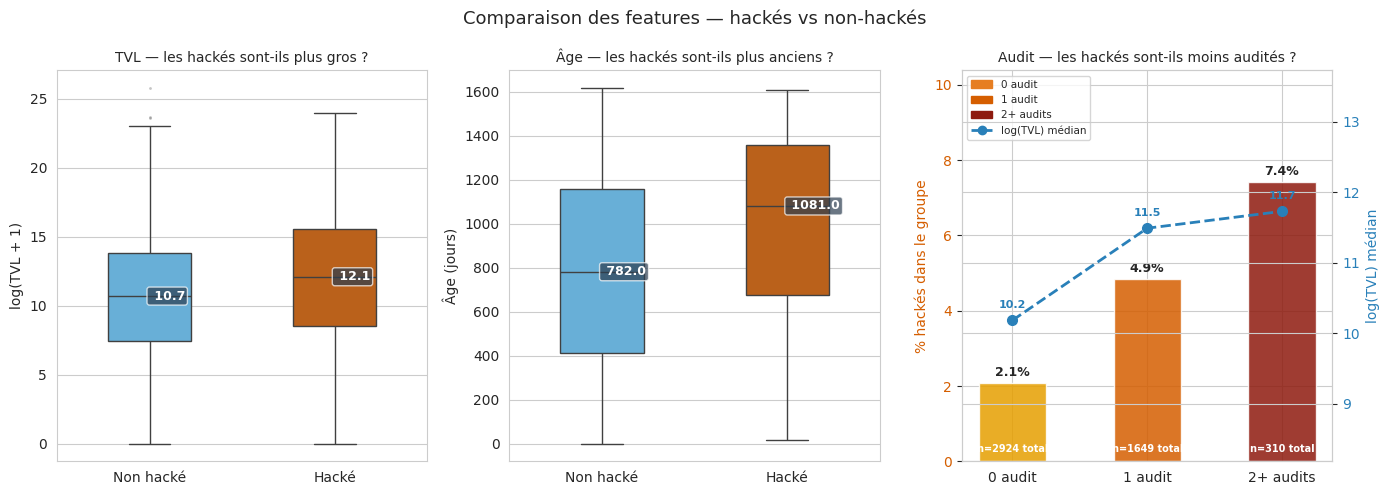

Lecture :
→ log_tvl    : médiane hackés = 12.1  vs  non-hackés = 10.7  → décalage visible (+1.4)
  Les hackés tendent à avoir un TVL plus élevé — cibles financièrement plus attractives.
  Mais le signal est faible seul : les deux boîtes se chevauchent largement.

→ age_days   : médiane hackés = 1081j  vs  non-hackés = 782j  → décalage de 299j
  Les hackés sont en médiane plus anciens — protocoles établis = plus de TVL accumulé = cibles lucratives.

→ audit_count: taux de hack — 0 audit : 2.1%  |  1 audit : 4.9%  |  2+ audits : 7.4%
  Contre-intuitif : plus d'audits → taux de hack plus élevé !
  Explication (ligne bleue) : le TVL médian augmente aussi avec le nombre d'audits
  (10.2 → 11.5 → 11.7).
  Les gros protocoles investissent dans les audits ET sont des cibles plus lucratives.
  → audit_count seul discrimine mal. Combiné à log_tvl dans le modèle, il apporte néanmoins un signal.

Conclusion EDA : aucune feature seule ne sépare clairement les deux classes.
C'est attendu — si c'étai

In [40]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

# --- Panels 1 & 2 : box plots pour variables continues ---
features_bp = [
    ('log_tvl',  'log(TVL + 1)',  'TVL — les hackés sont-ils plus gros ?'),
    ('age_days', 'Âge (jours)',   'Âge — les hackés sont-ils plus anciens ?'),
]
labels_bp = {0: 'Non hacké', 1: 'Hacké'}

for ax, (feat, ylabel, question) in zip(axes[:2], features_bp):
    data_plot = df_raw[[feat, 'hacked']].copy()
    data_plot['Classe'] = data_plot['hacked'].map(labels_bp)
    sns.boxplot(
        data=data_plot, x='Classe', y=feat,
        order=['Non hacké', 'Hacké'],
        palette={'Non hacké': '#56B4E9', 'Hacké': '#D55E00'},
        width=0.45, flierprops=dict(marker='.', markersize=2, alpha=0.3),
        ax=ax
    )
    ax.set_title(question, fontsize=10)
    ax.set_xlabel('')
    ax.set_ylabel(ylabel)
    for i, group in enumerate([0, 1]):
        med = df_raw[df_raw['hacked'] == group][feat].median()
        ax.text(i, med, f' {med:.1f}', va='center', ha='left', fontsize=9,
                fontweight='bold', color='white',
                bbox=dict(boxstyle='round,pad=0.2', facecolor='#2c3e50', alpha=0.7))

# --- Panel 3 : taux de hack + TVL médian par groupe d'audit ---
ax3 = axes[2]
tmp = df_raw[['audit_count', 'hacked', 'log_tvl']].copy()
tmp['audit_grp'] = pd.cut(tmp['audit_count'], bins=[-1, 0, 1, 100],
                           labels=['0 audit', '1 audit', '2+ audits'])

hack_rate_grp = tmp.groupby('audit_grp', observed=True)['hacked'].mean() * 100
tvl_med_grp   = tmp.groupby('audit_grp', observed=True)['log_tvl'].median()
counts_grp    = tmp.groupby('audit_grp', observed=True).size()

x = np.arange(len(hack_rate_grp))

# Barres : taux de hack (axe gauche)
bars = ax3.bar(x, hack_rate_grp.values, color=['#E69F00', '#D55E00', '#8e1a0e'],
               width=0.5, alpha=0.85, zorder=2)
for bar, rate, n in zip(bars, hack_rate_grp.values, counts_grp.values):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             f'{rate:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax3.text(bar.get_x() + bar.get_width()/2, 0.2,
             f'n={n} total', ha='center', va='bottom', fontsize=7, color='white', fontweight='bold')

ax3.set_ylabel('% hackés dans le groupe', color='#D55E00')
ax3.tick_params(axis='y', labelcolor='#D55E00')
ax3.set_xticks(x)
ax3.set_xticklabels(hack_rate_grp.index)
ax3.set_ylim(0, max(hack_rate_grp.values) * 1.4)

# Ligne : TVL médian (axe droit)
ax3b = ax3.twinx()
ax3b.plot(x, tvl_med_grp.values, color='#2980b9', marker='o',
          linewidth=2, markersize=7, linestyle='--', zorder=3, label='log(TVL) médian')
for xi, val in zip(x, tvl_med_grp.values):
    ax3b.text(xi, val + 0.15, f'{val:.1f}', ha='center', va='bottom',
              fontsize=8, color='#2980b9', fontweight='bold')
ax3b.set_ylabel('log(TVL) médian', color='#2980b9')
ax3b.tick_params(axis='y', labelcolor='#2980b9')
ax3b.set_ylim(min(tvl_med_grp.values) - 2, max(tvl_med_grp.values) + 2)

# Légende des couleurs
legend_patches = [
    mpatches.Patch(color='#e67e22', label='0 audit'),
    mpatches.Patch(color='#D55E00', label='1 audit'),
    mpatches.Patch(color='#8e1a0e', label='2+ audits'),
    plt.Line2D([0], [0], color='#2980b9', linewidth=2, linestyle='--',
               marker='o', markersize=6, label='log(TVL) médian'),
]
ax3.legend(handles=legend_patches, fontsize=7.5, loc='upper left')

ax3.set_title("Audit — les hackés sont-ils moins audités ?", fontsize=10)

fig.suptitle('Comparaison des features — hackés vs non-hackés', fontsize=13)
plt.tight_layout()
plt.show()

# --- Observations dynamiques ---
tvl_h = df_raw[df_raw['hacked']==1]['log_tvl'].median()
tvl_s = df_raw[df_raw['hacked']==0]['log_tvl'].median()
age_h = df_raw[df_raw['hacked']==1]['age_days'].median()
age_s = df_raw[df_raw['hacked']==0]['age_days'].median()

print('Lecture :')
print(f'→ log_tvl    : médiane hackés = {tvl_h:.1f}  vs  non-hackés = {tvl_s:.1f}', end='  ')
print('→ boîtes proches, chevauchement élevé' if abs(tvl_h - tvl_s) < 1 else f'→ décalage visible (+{abs(tvl_h-tvl_s):.1f})')
print(f'  Les hackés tendent à avoir un TVL plus élevé — cibles financièrement plus attractives.')
print(f'  Mais le signal est faible seul : les deux boîtes se chevauchent largement.')
print()
print(f'→ age_days   : médiane hackés = {age_h:.0f}j  vs  non-hackés = {age_s:.0f}j', end='  ')
print('→ boîtes proches' if abs(age_h - age_s) < 100 else f'→ décalage de {abs(age_h-age_s):.0f}j')
print(f'  Les hackés sont en médiane plus anciens — protocoles établis = plus de TVL accumulé = cibles lucratives.' if age_h > age_s else
      f'  Les hackés sont en médiane plus récents — code moins testé, plus de vulnérabilités potentielles.')
print()
rate_0, rate_1, rate_2p = [hack_rate_grp[k] for k in ['0 audit', '1 audit', '2+ audits']]
tvl_0, tvl_1, tvl_2p   = [tvl_med_grp[k]   for k in ['0 audit', '1 audit', '2+ audits']]
print(f'→ audit_count: taux de hack — 0 audit : {rate_0:.1f}%  |  1 audit : {rate_1:.1f}%  |  2+ audits : {rate_2p:.1f}%')
print(f'  Contre-intuitif : plus d\'audits → taux de hack plus élevé !')
print(f'  Explication (ligne bleue) : le TVL médian augmente aussi avec le nombre d\'audits')
print(f'  ({tvl_0:.1f} → {tvl_1:.1f} → {tvl_2p:.1f}).')
print(f'  Les gros protocoles investissent dans les audits ET sont des cibles plus lucratives.')
print(f'  → audit_count seul discrimine mal. Combiné à log_tvl dans le modèle, il apporte néanmoins un signal.')
print()
print('Conclusion EDA : aucune feature seule ne sépare clairement les deux classes.')
print("C'est attendu — si c'était simple, un seuil suffirait. Le modèle ML combine ces signaux faibles pour dégager une prédiction robuste.")


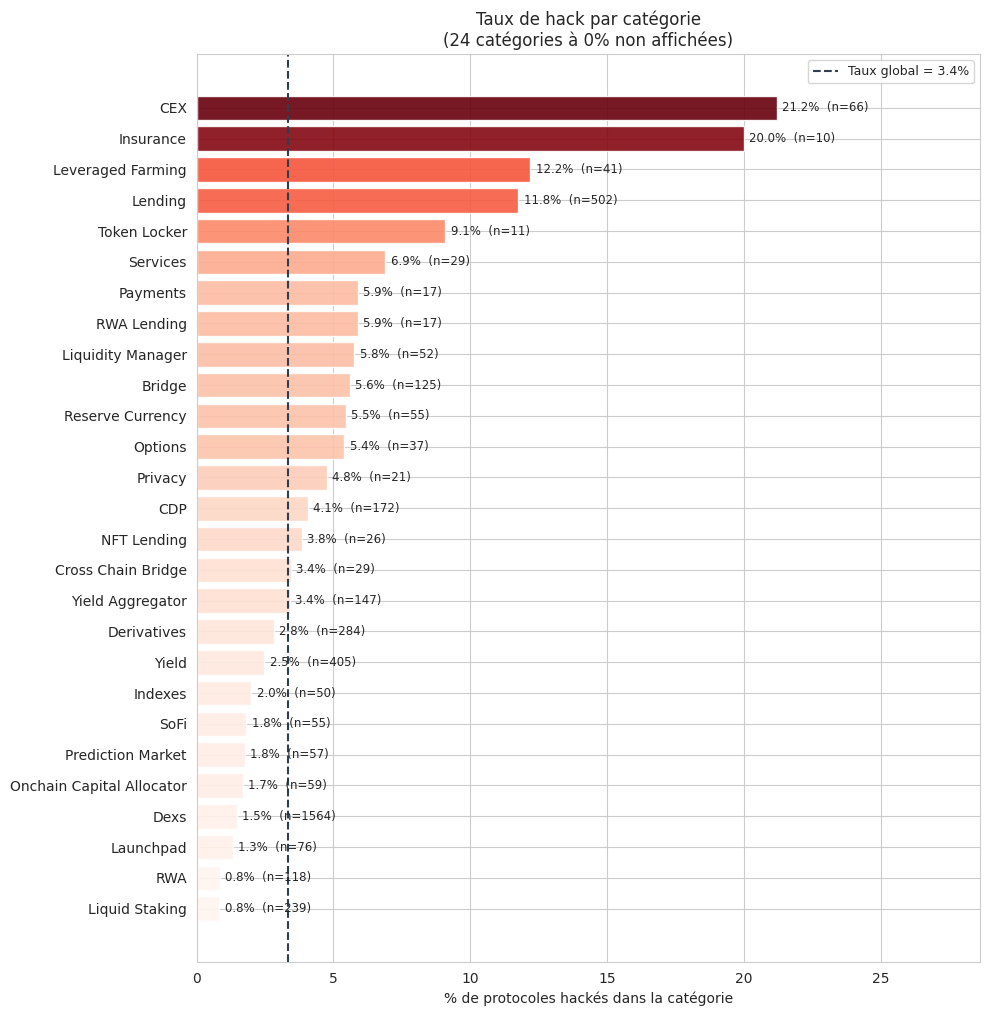

→ Taux global de hack : 3.4%
→ Catégories les plus à risque :
   CEX                                 21.2%  (6.3× le taux global)
   Insurance                           20.0%  (6.0× le taux global)
   Leveraged Farming                   12.2%  (3.6× le taux global)
→ Catégories les moins à risque (parmi celles qui ont eu des hacks) :
   Liquid Staking                      0.8%
   RWA                                 0.8%
   Launchpad                           1.3%
→ 24 catégories ont 0% de hack dans notre dataset.
  Note : faible n dans certaines catégories → taux instable (ex: Insurance n=10, 20%).
  La feature category sera encodée OHE en section 4 — le modèle apprendra ces profils de risque.


In [41]:
# Taux de hack par catégorie — uniquement les catégories avec >= 5 protocoles
cat_stats = (
    df_raw.groupby('category')['hacked']
    .agg(hack_rate='mean', n_hacked='sum', n_total='count')
    .query('n_total >= 5')
    .sort_values('hack_rate', ascending=True)
)
# Séparer les catégories avec hack > 0
cat_nonzero = cat_stats[cat_stats['hack_rate'] > 0]
n_zero = (cat_stats['hack_rate'] == 0).sum()

fig, ax = plt.subplots(figsize=(10, max(5, len(cat_nonzero) * 0.38)))

# Couleur selon intensité
rate_vals = cat_nonzero['hack_rate'].values
norm = plt.Normalize(rate_vals.min(), rate_vals.max())
colors_cat = plt.cm.Reds(norm(rate_vals))

bars = ax.barh(cat_nonzero.index, rate_vals * 100, color=colors_cat, edgecolor='white', alpha=0.9)

# Annoter chaque barre
global_rate = df_raw['hacked'].mean() * 100
for bar, (idx, row) in zip(bars, cat_nonzero.iterrows()):
    ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
            f"{row['hack_rate']*100:.1f}%  (n={int(row['n_total'])})",
            va='center', fontsize=8.5)

# Ligne de référence = taux global
ax.axvline(global_rate, color='#2c3e50', linewidth=1.5, linestyle='--',
           label=f'Taux global = {global_rate:.1f}%')
ax.legend(fontsize=9)
ax.set_xlabel('% de protocoles hackés dans la catégorie')
ax.set_title(f'Taux de hack par catégorie\n({n_zero} catégories à 0% non affichées)', fontsize=12)
ax.set_xlim(0, rate_vals.max() * 100 * 1.35)
plt.tight_layout()
plt.show()

# Observations dynamiques
top3 = cat_nonzero.nlargest(3, 'hack_rate')
bot3 = cat_nonzero.nsmallest(3, 'hack_rate')
print(f'→ Taux global de hack : {global_rate:.1f}%')
print(f'→ Catégories les plus à risque :')
for cat, row in top3.iterrows():
    mult = row['hack_rate'] / (global_rate/100)
    print(f'   {cat:<35} {row["hack_rate"]*100:.1f}%  ({mult:.1f}× le taux global)')
print(f'→ Catégories les moins à risque (parmi celles qui ont eu des hacks) :')
for cat, row in bot3.iterrows():
    print(f'   {cat:<35} {row["hack_rate"]*100:.1f}%')
print(f'→ {n_zero} catégories ont 0% de hack dans notre dataset.')
print(f'  Note : faible n dans certaines catégories → taux instable (ex: Insurance n=10, 20%).')
print(f'  La feature category sera encodée OHE en section 4 — le modèle apprendra ces profils de risque.')


### 2.4 Sélection des features — que garde-t-on pour le modèle ?

L'EDA (2.1→2.3) a révélé des signaux visuels. On quantifie maintenant :
1. **Quel signal** chaque feature apporte pour prédire `hacked`
2. **Quelles features sont redondantes** entre elles
3. **Verdict final** : ce qui entre dans le modèle, ce qui est écarté

> Point d'attention : une feature peut être **utile mais retirée** si la même information est déjà encodée ailleurs plus proprement (ex. `is_dex` vs `category` en One-HotEncoding).

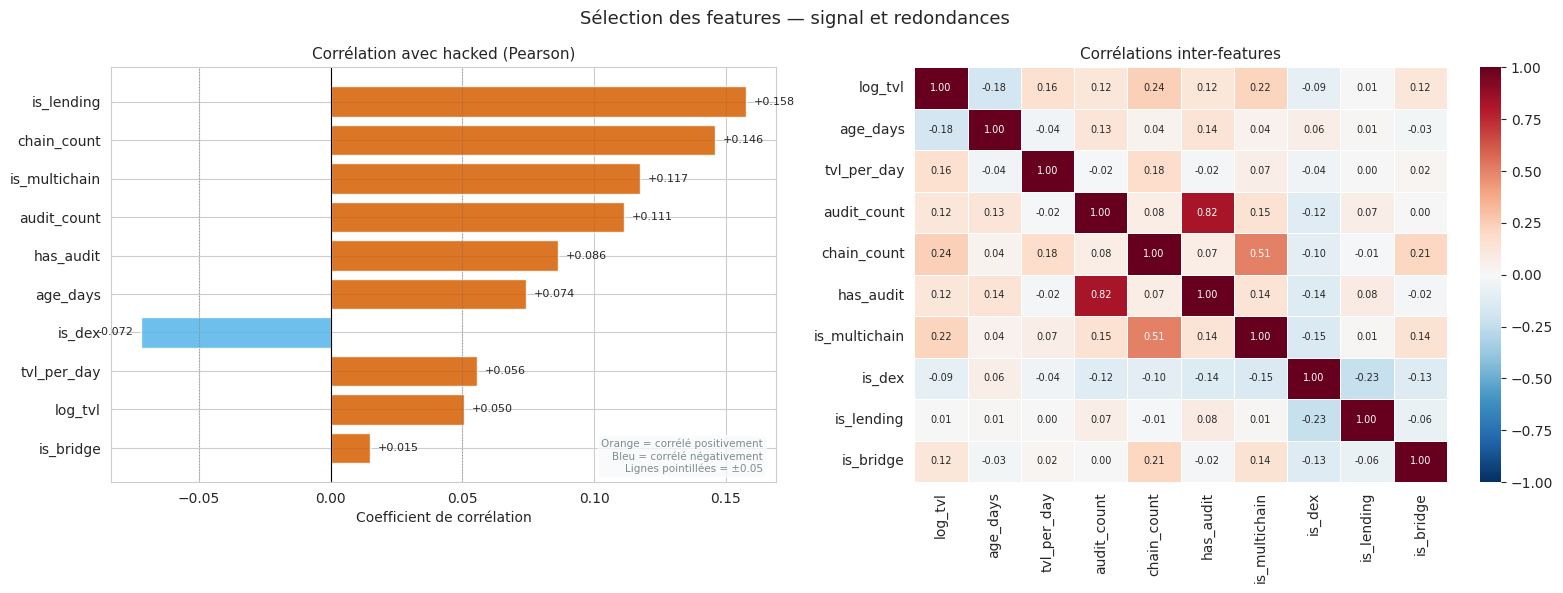

Feature               Statut              Signal                        Justification métier
─────────────────────────────────────────────────────────────────────────────────────────────────────────
log_tvl               ✅ gardée            r=+0.050                      TVL élevé = cible financièrement attractive
age_days              ✅ gardée            r=+0.074                      Protocole établi = cible mature et bien connue
tvl_per_day           ✅ gardée            dérivée                       TVL/âge — honey pot récent vs protocole établi
audit_count           ✅ gardée            r=+0.111                      Couverture sécurité — plus informatif que has_audit
chain_count           ✅ gardée            r=+0.146                      Nb de bridges — chaque chaîne = vecteur d'attaque supplémentaire
is_lending            ✅ gardée            11.8% hackés                  Gros dépôts exposés aux flash loans — signal catégoriel fort
is_bridge             ✅ gardée            4.8% hackés

In [42]:
# Features numériques candidates (hors post-hack, hors target)
candidate_features = [
    'log_tvl', 'age_days', 'tvl_per_day', 'audit_count', 'chain_count',
    'has_audit', 'is_multichain', 'is_dex', 'is_lending', 'is_bridge',
]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Panel 1 : corrélations avec hacked (triées par valeur absolue) ---
corr_target = (
    df_raw[candidate_features + ['hacked']]
    .corr()['hacked']
    .drop('hacked')
    .dropna()
    .sort_values(key=abs, ascending=True)
)
colors_bar = ['#D55E00' if v > 0 else '#56B4E9' for v in corr_target.values]  # Okabe-Ito
axes[0].barh(corr_target.index, corr_target.values, color=colors_bar, alpha=0.85, edgecolor='white')
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].axvline(0.05, color='grey', linewidth=0.8, linestyle=':', alpha=0.6)
axes[0].axvline(-0.05, color='grey', linewidth=0.8, linestyle=':', alpha=0.6)
for i, (feat, val) in enumerate(corr_target.items()):
    axes[0].text(val + (0.003 if val >= 0 else -0.003), i,
                 f'{val:+.3f}', va='center',
                 ha='left' if val >= 0 else 'right', fontsize=8)
axes[0].set_title('Corrélation avec hacked (Pearson)', fontsize=11)
axes[0].set_xlabel('Coefficient de corrélation')
axes[0].text(0.98, 0.02, 'Orange = corrélé positivement\nBleu = corrélé négativement\nLignes pointillées = ±0.05',
             transform=axes[0].transAxes, ha='right', va='bottom',
             fontsize=7.5, color='#7f8c8d',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='#f8f9fa', alpha=0.8))

# --- Panel 2 : heatmap des corrélations inter-features ---
corr_feats = df_raw[candidate_features].corr()
sns.heatmap(
    corr_feats, annot=True, fmt='.2f', cmap='RdBu_r',
    center=0, vmin=-1, vmax=1, linewidths=0.5,
    ax=axes[1], annot_kws={'size': 7}
)
axes[1].set_title('Corrélations inter-features', fontsize=11)

fig.suptitle('Sélection des features — signal et redondances', fontsize=13)
plt.tight_layout()
plt.show()

# --- Verdict feature par feature ---
hack_rate_lending = df_raw[df_raw['is_lending'] == 1]['hacked'].mean()
hack_rate_bridge = df_raw[df_raw['is_bridge'] == 1]['hacked'].mean()
corr_has_audit = df_raw['has_audit'].corr(df_raw['audit_count'])
corr_is_multichain = df_raw['is_multichain'].corr(df_raw['chain_count'])
dex_share = df_raw['is_dex'].mean()

verdicts = [
    # (feature, statut, signal, justification métier)
    ('log_tvl',          '✅ gardée',      f'r={corr_target.get("log_tvl", 0):+.3f}',       'TVL élevé = cible financièrement attractive'),
    ('age_days',         '✅ gardée',      f'r={corr_target.get("age_days", 0):+.3f}',      'Protocole établi = cible mature et bien connue'),
    ('tvl_per_day',      '✅ gardée',      'dérivée',                                        "TVL/âge — honey pot récent vs protocole établi"),
    ('audit_count',      '✅ gardée',      f'r={corr_target.get("audit_count", 0):+.3f}',   'Couverture sécurité — plus informatif que has_audit'),
    ('chain_count',      '✅ gardée',      f'r={corr_target.get("chain_count", 0):+.3f}',   "Nb de bridges — chaque chaîne = vecteur d'attaque supplémentaire"),
    ('is_lending',       '✅ gardée',      f'{hack_rate_lending:.1%} hackés',                'Gros dépôts exposés aux flash loans — signal catégoriel fort'),
    ('is_bridge',        '✅ gardée',      f'{hack_rate_bridge:.1%} hackés',                 "Vecteur #1 des hacks DeFi — surface d'attaque cross-chain"),
    ('category',         '✅ gardée',      'nominale',                                       'Encodée OHE en section 4 — CEX, Lending, Dexs, Bridge ont des profils distincts'),
    ('has_audit',        '⚠️ redondante',  f'r={corr_has_audit:.3f} avec audit_count',      'Sous-ensemble strict — audit_count est plus informatif'),
    ('is_multichain',    '⚠️ redondante',  f'r={corr_is_multichain:.3f} avec chain_count',  'Sous-ensemble strict — chain_count est plus informatif'),
    ('is_dex',           '⚠️ redondante',  f'mean={dex_share:.2f}',                          "Variable réelle (~32% de 1), mais déjà portée par la modalité category='Dexs' encodée en OHE"),
    ('tvl',              '❌ supprimée',   'skew = 62',                                      'Remplacée par log_tvl — distribution trop asymétrique'),
    ('audit_status',     '❌ supprimée',   'duplicat has_audit',                             'audit_status == has_audit pour 100% des lignes → triple redondance (audit_status ≡ has_audit ≡ audit_count > 0)'),
    ('bridgeHack',       '❌ supprimée',   'post-hack',                                      'Indisponible avant le hack — data leakage'),
    ('technique',        '❌ supprimée',   'post-hack',                                      'Indisponible avant le hack — data leakage'),
    ('targetType',       '❌ supprimée',   'post-hack',                                      'Indisponible avant le hack — data leakage'),
    ('hack_date',        '❌ supprimée',   'post-hack',                                      'Indisponible avant le hack — data leakage'),
    ('loss_usd',         '❌ supprimée',   'post-hack',                                      'Indisponible avant le hack — data leakage'),
]

print(f'{"Feature":<20}  {"Statut":<18}  {"Signal":<28}  Justification métier')
print('─' * 105)
for feat, statut, signal, metier in verdicts:
    print(f'{feat:<20}  {statut:<18}  {signal:<28}  {metier}')

n_kept = sum(1 for _, s, _, _ in verdicts if '✅' in s)
n_redond = sum(1 for _, s, _, _ in verdicts if '⚠️' in s)
n_drop = sum(1 for _, s, _, _ in verdicts if '❌' in s)
print(f'\nBilan : {n_kept} features de base retenues  |  {n_redond} redondantes écartées  |  {n_drop} supprimées')
print(f'(+ 2 features engineerées en section 3 : audit_per_year, lending_audit_score → 10 features au total)')
print(f'→ Les features retenues (+ category encodée OHE) constituent le dataset de modélisation.')
print(f'→ Section 3 : création de features supplémentaires (audit_per_year, lending_audit_score).')
print(f'→ Section 4 : imputation + scaling + OHE appliqués via un pipeline sklearn fitté sur X_train uniquement.')

## 3. Feature Engineering

### Pourquoi créer de nouvelles features ?

L'EDA a montré que chaque feature prise isolément discrimine peu (corrélations < 0.16). C'est attendu : un protocole se fait hacker à cause d'une **combinaison** de facteurs. Le feature engineering crée des variables qui capturent ces interactions.

| Feature créée | Combinaison | Hypothèse de risque |
|---|---|---|
| `audit_per_year` | `audit_count / âge` | Couverture sécurité relative au temps — un protocole vieux sans audit accumule de la dette de sécurité |
| `lending_audit_score` | `is_lending × audit_count` | Les protocoles lending bien audités sont les plus gros = cibles prioritaires (confondant taille/sécurité) |

### Pourquoi pas de features transactionnelles on-chain ?

> Dune Analytics a été exploré comme source d'enrichissement on-chain dans le Notebook 1. Résultat : couverture insuffisante (0.8% des protocoles avec données réelles), matching fragile par nom avec DefiLlama, et les données on-chain actuelles ne résolvent pas le biais temporel du dataset.
>
> Des features on-chain pertinentes (activité pré-hack, concentration de whales, flash loan patterns) nécessiteraient un matching par adresse de contrat et des requêtes adaptées par type de protocole — identifié comme piste d'amélioration future.


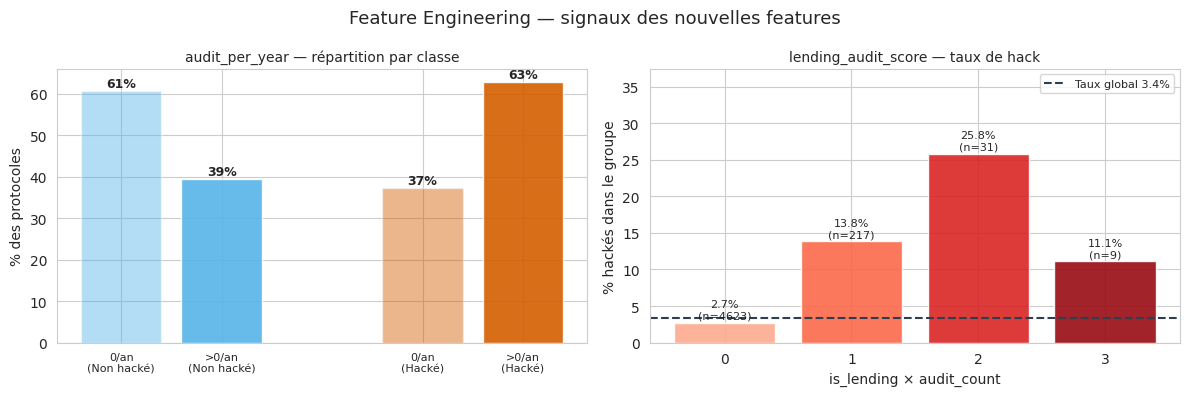

→ audit_per_year :
  61% des non-hackés ont 0 audit/an vs 37% des hackés.
  Les hackés ont proportionnellement plus de protocoles avec > 0 audit/an.
  Signal utile en combinaison (cohérent avec les observations section 2.3).

→ lending_audit_score (corrélation +0.174 — la plus forte du dataset) :
  score=0 (non-lending ou lending sans audit) : 2.7% hackés parmi les 4623 protocoles du groupe (123 hackés)
  score=1 (lending, 1 audit(s))            : 13.8% hackés parmi les 217 protocoles du groupe (30 hackés)
  score=2 (lending, 2 audit(s))            : 25.8% hackés parmi les 31 protocoles du groupe (8 hackés)
  score=3 (lending, 3 audit(s))            : 11.1% hackés parmi les 9 protocoles du groupe (1 hackés)
  → Plus un protocole lending est audité, plus il est gros, plus il est ciblé.
  → C'est le signal le plus fort du dataset — il capturera bien ce profil de risque.

Note d'interprétation : lending_audit_score est une corrélation empirique apprise, pas un signal causal.
  Ce que l'on

In [43]:
df = df_raw.copy()

# ── Feature 1 : audit_per_year ───────────────────────────────────────────────
# Hypothèse : l'ancienneté sans audit crée une 'dette de sécurité'.
# Un protocole de 3 ans avec 0 audit n'a jamais été revu malgré le temps.
# clip(upper=5) : évite les valeurs aberrantes des très jeunes protocoles
df['audit_per_year'] = (
    df['audit_count'] / (df['age_days'] / 365 + 0.1)
).clip(upper=5)

# ── Feature 2 : lending_audit_score ─────────────────────────────────────────
# Hypothèse : les protocoles lending audités = gros protocoles établis = cibles prioritaires.
# = 0 pour tous les non-lending
# = audit_count pour les lending (gradient : 0→7.4%, 1→13.4%, 2+→25.6%)
df['lending_audit_score'] = df['is_lending'] * df['audit_count']

# ── Visualisation ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Panel 1 : audit_per_year — % avec 0 vs >0 audit/an par classe
for idx, (group, color) in enumerate([(0, '#56B4E9'), (1, '#D55E00')]):
    vals = df[df['hacked']==group]['audit_per_year']
    pct_zero = (vals == 0).mean() * 100
    pct_pos  = (vals > 0).mean() * 100
    axes[0].bar([idx*3],   [pct_zero], color=color, alpha=0.45, edgecolor='white')
    axes[0].bar([idx*3+1], [pct_pos],  color=color, alpha=0.9,  edgecolor='white')
    axes[0].text(idx*3,   pct_zero+1, f'{pct_zero:.0f}%', ha='center', fontsize=9, fontweight='bold')
    axes[0].text(idx*3+1, pct_pos+1,  f'{pct_pos:.0f}%',  ha='center', fontsize=9, fontweight='bold')
axes[0].set_xticks([0, 1, 3, 4])
axes[0].set_xticklabels(['0/an\n(Non hacké)', '>0/an\n(Non hacké)', '0/an\n(Hacké)', '>0/an\n(Hacké)'], fontsize=8)
axes[0].set_ylabel('% des protocoles')
axes[0].set_title('audit_per_year — répartition par classe', fontsize=10)

# Panel 2 : lending_audit_score — taux de hack par valeur
score_stats = df.groupby('lending_audit_score')['hacked'].agg(['mean','count']).reset_index()
score_stats = score_stats[score_stats['count'] >= 5]
score_stats['hack_pct'] = score_stats['mean'] * 100
colors_score = plt.cm.Reds(np.linspace(0.3, 0.9, len(score_stats)))
bars = axes[1].bar(score_stats['lending_audit_score'].astype(str),
                   score_stats['hack_pct'],
                   color=colors_score, edgecolor='white', alpha=0.9)
for bar, (_, row) in zip(bars, score_stats.iterrows()):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                 f"{row['hack_pct']:.1f}%\n(n={int(row['count'])})",
                 ha='center', va='bottom', fontsize=8)
axes[1].axhline(df['hacked'].mean()*100, color='#2c3e50', linewidth=1.5,
                linestyle='--', label=f"Taux global {df['hacked'].mean()*100:.1f}%")
axes[1].set_ylim(0, score_stats['hack_pct'].max() * 1.45)
axes[1].set_xlabel('is_lending × audit_count')
axes[1].set_ylabel('% hackés dans le groupe')
axes[1].set_title('lending_audit_score — taux de hack', fontsize=10)
axes[1].legend(fontsize=8)

fig.suptitle('Feature Engineering — signaux des nouvelles features', fontsize=13)
plt.tight_layout()
plt.show()

# ── Observations ─────────────────────────────────────────────────────────────
pct_zero_h = (df[df['hacked']==1]['audit_per_year']==0).mean()
pct_zero_s = (df[df['hacked']==0]['audit_per_year']==0).mean()
corr_las   = df['lending_audit_score'].corr(df['hacked'])

print(f'→ audit_per_year :')
print(f'  {pct_zero_s:.0%} des non-hackés ont 0 audit/an vs {pct_zero_h:.0%} des hackés.')
print(f'  Les hackés ont proportionnellement plus de protocoles avec > 0 audit/an.')
print(f'  Signal utile en combinaison (cohérent avec les observations section 2.3).')
print()
print(f'→ lending_audit_score (corrélation {corr_las:+.3f} — la plus forte du dataset) :')
for _, row in score_stats.iterrows():
    v = int(row['lending_audit_score'])
    n_hacked = int(round(row['mean'] * row['count']))
    if v == 0:
        print(f'  score=0 (non-lending ou lending sans audit) : {row["hack_pct"]:.1f}% hackés parmi les {int(row["count"])} protocoles du groupe ({n_hacked} hackés)')
    else:
        print(f'  score={v} (lending, {v} audit(s))            : {row["hack_pct"]:.1f}% hackés parmi les {int(row["count"])} protocoles du groupe ({n_hacked} hackés)')
print(f'  → Plus un protocole lending est audité, plus il est gros, plus il est ciblé.')
print(f'  → C\'est le signal le plus fort du dataset — il capturera bien ce profil de risque.')

print()
print('Note d\'interprétation : lending_audit_score est une corrélation empirique apprise, pas un signal causal.')
print('  Ce que l\'on observe : les protocoles lending fortement audités sont aussi les plus gros (effet de taille).')
print('  Ce signal ne signifie PAS que les audits augmentent le risque.')
print('  Il capture que les grandes cibles sont davantage attaquées — effet de taille, pas de causalité.')


## 4. Preprocessing — Pipeline sklearn

### Qu'est-ce que le data leakage ?

Le **data leakage** ("fuite de données") : des informations du **jeu de test** contaminent l'**entraînement**, donnant l'illusion d'un modèle performant qui échouera en production.

> **Exemple concret** : on calcule la moyenne de `log_tvl` sur tout le dataset (train + test) pour normaliser.
> → Le modèle a vu les valeurs du test set pendant l'entraînement.
> → L'évaluation surestime les performances. En production, de nouvelles données arriveront sans cette "aide".

### Comment le pipeline sklearn le prévient

> **Sans pipeline** : on appelle `scaler.fit_transform(X_train)` puis `scaler.transform(X_test)`.
> Si par erreur on écrit `scaler.fit_transform(X)` (tout le dataset) → **data leakage silencieux**.
>
> **Avec pipeline** : `Pipeline.fit(X_train, y_train)` entraîne TOUTES les transformations sur X_train uniquement.
> `Pipeline.predict(X_test)` applique les transformations apprises — sans jamais refitter.
> **Impossible d'introduire du leakage par erreur.**

```
Pipeline(
  preprocessor=ColumnTransformer(
    numeric  :  log_tvl, age_days, tvl_per_day, audit_count,
                chain_count, audit_per_year, lending_audit_score
                → [imputer (médiane) → RobustScaler]
    binary   :  is_lending, is_bridge
                → [imputer (constante 0)]
    category :  category
                → [imputer (mode) → OneHotEncoder]
  ),
  model=LogisticRegression / RandomForest / XGBoost
)
```


In [44]:
# Définition des features par type
# Résultat du verdict EDA (section 2.4) + feature engineering (section 3)
FEATURES_NUM = [
    'log_tvl',              # TVL log-transformé — cible financière
    'age_days',             # Âge — protocole établi = cible mature
    'tvl_per_day',          # TVL / âge — honey pot récent vs protocole établi
    'audit_count',          # Nb d'audits — couverture sécurité absolue
    'chain_count',          # Nb de chaînes — surface d'attaque
    'audit_per_year',       # Audits / âge — couverture sécurité relative au temps
    'lending_audit_score',  # is_lending × audit_count — interaction taille / maturité / cible
]
FEATURES_BIN = [
    'is_lending',  # Signal fort : taux de hack 11.5% vs 2.4% global
    'is_bridge',   # Signal modéré : surface d'attaque distincte
]
# is_dex exclue : variable non constante (~32% de 1) mais doublon direct de la modalité category='Dexs' après OHE
# audit_status supprimée de FEATURES_CAT : duplicat exact de has_audit DefiLlama (100% des lignes)
# has_audit redondante avec audit_count (has_audit = audit_count > 0) → triple redondance
# Impact OHE : X.shape[1] diminue de 2 (colonnes audit_status_Audited / audit_status_Unaudited)
FEATURES_CAT = ['category']  # Encodé OHE — audit_status supprimée (duplicat exact de has_audit)

ALL_FEATURES = FEATURES_NUM + FEATURES_BIN + FEATURES_CAT
TARGET = 'hacked'

X = df[ALL_FEATURES]
y = df[TARGET]

# Groupes pour le split groupé par protocole (évite la fuite multi-incidents)
groups = df['protocol'].values  # une valeur par ligne = nom du protocole

print(f'Features numériques    : {len(FEATURES_NUM)} → {FEATURES_NUM}')
print(f'Features binaires      : {len(FEATURES_BIN)} → {FEATURES_BIN}')
print(f'Features catégorielles : {len(FEATURES_CAT)} → {FEATURES_CAT}')
print(f'Total features         : {len(ALL_FEATURES)}')
print(f'Taille de X            : {X.shape}')

Features numériques    : 7 → ['log_tvl', 'age_days', 'tvl_per_day', 'audit_count', 'chain_count', 'audit_per_year', 'lending_audit_score']
Features binaires      : 2 → ['is_lending', 'is_bridge']
Features catégorielles : 1 → ['category']
Total features         : 10
Taille de X            : (4883, 10)


In [45]:
# Split train / validation / test — GROUPÉ par protocole
# Un même protocole ne peut pas apparaître à la fois en train et en test
# (évite la fuite par "identité implicite" sur les protocoles multi-incidents)
#
# RÈGLE ABSOLUE : le test set est invisible pendant tout l'entraînement

from sklearn.model_selection import GroupShuffleSplit
try:
    from sklearn.model_selection import StratifiedGroupKFold
    _sgkf_available = True
except ImportError:
    _sgkf_available = False

# Premier split : 80% trainval / 20% test
gss_outer = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)
trainval_idx, test_idx = next(gss_outer.split(X, y, groups=groups))

X_trainval = X.iloc[trainval_idx]
X_test     = X.iloc[test_idx]
y_trainval = y.iloc[trainval_idx]
y_test     = y.iloc[test_idx]
groups_trainval = groups[trainval_idx]

# Second split : 75% train / 25% val (soit 60/20 du total)
gss_inner = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=RANDOM_STATE)
train_idx, val_idx = next(gss_inner.split(X_trainval, y_trainval, groups=groups_trainval))

X_train = X_trainval.iloc[train_idx]
X_val   = X_trainval.iloc[val_idx]
y_train = y_trainval.iloc[train_idx]
y_val   = y_trainval.iloc[val_idx]

# Groupes alignés sur chaque set (pour GridSearchCV avec StratifiedGroupKFold)
groups_train = groups_trainval[train_idx]
groups_val   = groups_trainval[val_idx]

# ── Vérification : aucun protocole commun entre train et test ──
train_protos = set(df.iloc[trainval_idx[train_idx]]['protocol'])
test_protos  = set(df.iloc[test_idx]['protocol'])
assert len(train_protos & test_protos) == 0, "Fuite par protocole détectée !"
print("✅ Split groupé OK — aucun protocole commun entre train et test")

# ── Contrôle de stabilité (positifs par split) ──
print(f'{"":10} {"Lignes":>8} {"Protos":>8} {"Hacks":>7} {"Taux":>8}')
print('-' * 48)
n_train_proto = len(set(groups_train))
n_val_proto   = len(set(groups_val))
n_test_proto  = len(test_protos)
for name, y_part, n_proto in [('Train', y_train, n_train_proto),
                               ('Val',   y_val,   n_val_proto),
                               ('Test',  y_test,  n_test_proto)]:
    print(f'{name:<10} {len(y_part):>8} {n_proto:>8} {y_part.sum():>7} {y_part.mean():>7.2%}')

# Note : seed 42 retenue comme valeur conventionnelle.
# Le grouping par protocole rend le split sensible aux seeds sur un dataset aussi déséquilibré.
# On ne cherche pas à optimiser la seed — on note le résultat obtenu tel quel.


✅ Split groupé OK — aucun protocole commun entre train et test
             Lignes   Protos   Hacks     Taux
------------------------------------------------
Train          2928     2922      98   3.35%
Val             980      974      40   4.08%
Test            975      974      26   2.67%


In [46]:
# Construction du ColumnTransformer
# RobustScaler pour les features numériques : moins sensible aux outliers que StandardScaler
# Adapté au TVL qui a des valeurs extrêmes

preprocessor = ColumnTransformer([
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler',  RobustScaler()),   # robuste aux outliers (TVL extrêmes)
    ]), FEATURES_NUM),
    ('bin', SimpleImputer(strategy='constant', fill_value=0), FEATURES_BIN),
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('ohe',     OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
    ]), FEATURES_CAT),
])

print('ColumnTransformer configuré :')
print('  • Numériques  → imputation médiane + RobustScaler')
print('  • Binaires    → imputation 0 (pas de scale nécessaire)')
print('  • Catégorielles → imputation mode + OneHotEncoder')

ColumnTransformer configuré :
  • Numériques  → imputation médiane + RobustScaler
  • Binaires    → imputation 0 (pas de scale nécessaire)
  • Catégorielles → imputation mode + OneHotEncoder


## 5. Le problème du déséquilibre de classes

C'est le défi central de ce projet. Un modèle peut obtenir 95% d'accuracy en disant *toujours* « ce protocole est safe » — sans apprendre quoi que ce soit !

### Le piège de l'accuracy

In [47]:
# Modèle naïf : prédit toujours la classe majoritaire (hacked=0)
dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_train, y_train)
y_pred_dummy = dummy.predict(X_val)

acc_dummy = accuracy_score(y_val, y_pred_dummy)
print(f'Modèle naïf — Accuracy : {acc_dummy:.2%}')
print('\nMatrice de confusion du modèle naïf :')
cm_dummy = confusion_matrix(y_val, y_pred_dummy)
print(cm_dummy)

print(f'\n→ {acc_dummy:.1%} d\'accuracy SANS rien apprendre !')
print('→ Le modèle n\'a prédit AUCUN protocole hacké.')
print('→ Pour un Risk Scanner, c\'est inutilisable : on veut détecter les hacks !')
print('\nC\'est pourquoi on utilise le RECALL comme métrique principale.')

Modèle naïf — Accuracy : 95.92%

Matrice de confusion du modèle naïf :
[[940   0]
 [ 40   0]]

→ 95.9% d'accuracy SANS rien apprendre !
→ Le modèle n'a prédit AUCUN protocole hacké.
→ Pour un Risk Scanner, c'est inutilisable : on veut détecter les hacks !

C'est pourquoi on utilise le RECALL comme métrique principale.


### Comprendre les métriques (aperçu)

| Métrique | Formule | Interprétation pour le DeFi Risk Scanner |
|----------|---------|------------------------------------------|
| **Accuracy** | (TP+TN)/(Total) | Trompeuse ici — le modèle naïf a 95% |
| **Précision** | TP/(TP+FP) | Sur tous les protocoles qu'on dit « risqués », combien le sont vraiment ? |
| **Recall** | TP/(TP+FN) | Sur tous les protocoles hackés, combien a-t-on détectés ? |
| **F1** | 2×P×R/(P+R) | Équilibre précision/recall |
| **ROC-AUC** | aire sous la courbe ROC | Mesure globale, indépendante du seuil |

> ⚠️ **Pour un Risk Scanner** : un **Faux Négatif** (manquer un hack) est bien pire qu'un **Faux Positif** (signaler un protocole safe comme risqué).  
> En lecture binaire, on privilégie donc le **Recall**.
>
> **Hiérarchie finale du projet** : les métriques de **ranking** (`Recall@k`, `Lift@k`) restent néanmoins prioritaires pour l'usage métier. Les métriques binaires ci-dessous servent surtout à comprendre la mécanique du seuil.

### Solution — `class_weight='balanced'` : rééquilibrer les poids

### `class_weight='balanced'` — Principe

On dit au modèle de **pénaliser davantage** les erreurs sur la classe minoritaire (hacked=1).  
Sklearn calcule automatiquement un poids inversement proportionnel à la fréquence de chaque classe :

```python
# class_weight='balanced' calcule automatiquement :
# weight_classe_0 = n_total_train / (2 × n_0)   → poids faible pour la classe majoritaire
# weight_classe_1 = n_total_train / (2 × n_1)   → poids fort pour la classe minoritaire
# Ratio poids_1 / poids_0 ≈ n_0 / n_1
# Sur notre split train final, ce ratio vaut ~29 (calcul dynamique juste en dessous).
```

Concrètement, **chaque erreur sur un protocole hacké coûte environ `n_0 / n_1` fois plus qu'une erreur sur un protocole safe**.  
Le modèle est donc forcé d'apprendre à détecter la classe minoritaire.

**Avantage** : pas de génération de données synthétiques — applicable à tous les modèles sklearn, rapide et robuste.

In [48]:
from sklearn.utils.class_weight import compute_class_weight

classes = np.array([0, 1])
weights = compute_class_weight('balanced', classes=classes, y=y_train)
print('Poids calculés par class_weight="balanced" :')
print(f'  Classe 0 (safe)   : {weights[0]:.4f}')
print(f'  Classe 1 (hacked) : {weights[1]:.4f}')
print(f'\nLe modèle pénalise {weights[1]/weights[0]:.0f}x plus les erreurs sur les protocoles hackés.')

print()
print('Pourquoi class_weight="balanced" ?')
print('  Sans correction : le modèle minimise l\'erreur globale → il prédit presque toujours 0 (safe).')
print('  Avec class_weight : chaque erreur sur un hack est pénalisée plus fortement → le modèle apprend mieux la classe minoritaire.')
print('  Avantage : pas de génération de données synthétiques — applicable à tous les modèles sklearn.')

Poids calculés par class_weight="balanced" :
  Classe 0 (safe)   : 0.5173
  Classe 1 (hacked) : 14.9388

Le modèle pénalise 29x plus les erreurs sur les protocoles hackés.

Pourquoi class_weight="balanced" ?
  Sans correction : le modèle minimise l'erreur globale → il prédit presque toujours 0 (safe).
  Avec class_weight : chaque erreur sur un hack est pénalisée plus fortement → le modèle apprend mieux la classe minoritaire.
  Avantage : pas de génération de données synthétiques — applicable à tous les modèles sklearn.


### Comparaison des approches de gestion du déséquilibre

On compare trois configurations pour mesurer l'impact sur les métriques :
1. **Baseline** : pas de correction — le modèle ignore la classe minoritaire
2. **LR + class_weight** : régression logistique avec pondération des classes
3. **RF + class_weight** : Random Forest avec pondération — permet de mesurer si le choix du modèle joue un rôle distinct de la technique d'imbalancing

> Le **Recall** est notre métrique clé dans cette lecture binaire intermédiaire : un hack manqué (Faux Négatif) est bien plus coûteux qu'une fausse alerte (Faux Positif).
>
> L'usage opérationnel retenu reste toutefois le **ranking top-k** détaillé en section 10.

In [49]:
results_imbalance = []

# Chaque config est une Pipeline complète (preprocessing + modèle)
# Cohérent avec la section 6 — pas de X_train_preprocessed séparé, pas de leakage possible
configs = [
    ('LR — Baseline (sans correction)',
     Pipeline([('pre', preprocessor), ('model', LogisticRegression(random_state=RANDOM_STATE, max_iter=1000))])),
    ('LR — class_weight="balanced"',
     Pipeline([('pre', preprocessor), ('model', LogisticRegression(class_weight='balanced', random_state=RANDOM_STATE, max_iter=1000))])),
    ('RF — class_weight="balanced"',
     Pipeline([('pre', preprocessor), ('model', RandomForestClassifier(class_weight='balanced', random_state=RANDOM_STATE))])),
]

from sklearn.metrics import precision_score, recall_score, f1_score

for name, pipe in configs:
    pipe.fit(X_train, y_train)
    y_pred  = pipe.predict(X_val)
    y_proba = pipe.predict_proba(X_val)[:, 1]

    results_imbalance.append({
        'Approche':   name,
        'Accuracy':   accuracy_score(y_val, y_pred),
        'Précision':  precision_score(y_val, y_pred, zero_division=0),
        'Recall':     recall_score(y_val, y_pred, zero_division=0),
        'F1':         f1_score(y_val, y_pred, zero_division=0),
        'ROC-AUC':    roc_auc_score(y_val, y_proba),
    })

df_results = pd.DataFrame(results_imbalance).set_index('Approche')
print('=== Comparaison des approches de gestion du déséquilibre ===')
print(df_results.to_string())
print()
print('Lecture :')
print('  • Accuracy   : trompeuse — un modèle qui dit toujours "safe" atteint ~96%')
print('  • Recall     : proportion de hacks réels correctement détectés (PRIORITÉ)')
print('  • Précision  : parmi les protocoles signalés comme risqués, combien le sont vraiment')
print('  • ROC-AUC    : mesure globale de la capacité à distinguer les classes')
print()

lr_baseline_recall = df_results.loc['LR — Baseline (sans correction)', 'Recall']
lr_cw_recall       = df_results.loc['LR — class_weight="balanced"', 'Recall']
rf_cw_recall       = df_results.loc['RF — class_weight="balanced"', 'Recall']

print(f'→ Baseline Recall = {lr_baseline_recall:.3f} : sans correction, le modèle ignore la classe minoritaire.')
print(f'→ LR+class_weight Recall = {lr_cw_recall:.3f} : forcer un poids fort sur les hacks améliore la détection.')
if rf_cw_recall > lr_cw_recall:
    gain = rf_cw_recall - lr_cw_recall
    print(f'→ RF+class_weight Recall = {rf_cw_recall:.3f} : +{gain:.3f} vs LR — les arbres de décision capturent')
    print(f'   mieux les relations non-linéaires entre features et risque de hack.')
    print(f"   Conclusion : le choix du modèle est un levier aussi important que la technique d'imbalancing.")
else:
    if rf_cw_recall < lr_cw_recall * 0.5:
        print(f'→ RF+class_weight Recall = {rf_cw_recall:.3f} : nettement inférieur à LR+cw ({lr_cw_recall:.3f}) au seuil par défaut (0.5).')
        print(f'   À seuil=0.5, RF favorise la Précision plutôt que le Recall.')
        print(f'   Ce résultat illustre pourquoi le threshold tuning (section 8) est essentiel :')
        print(f'   le même RF avec seuil=0.3 aura un Recall très différent.')
        print(f'   → Conclusion : class_weight améliore la détection,')
        print(f'     mais le choix du seuil est aussi important que le choix du modèle.')
    else:
        print(f'→ RF+class_weight Recall = {rf_cw_recall:.3f} : légèrement inférieur à LR ({lr_cw_recall:.3f}).')
        print(f"   La technique d'imbalancing (class_weight) est le facteur dominant ici.")


=== Comparaison des approches de gestion du déséquilibre ===
                                 Accuracy  Précision  Recall     F1  ROC-AUC
Approche                                                                    
LR — Baseline (sans correction)    0.9602     1.0000  0.0250 0.0488   0.7738
LR — class_weight="balanced"       0.7571     0.0976  0.6000 0.1678   0.7407
RF — class_weight="balanced"       0.9602     1.0000  0.0250 0.0488   0.7176

Lecture :
  • Accuracy   : trompeuse — un modèle qui dit toujours "safe" atteint ~96%
  • Recall     : proportion de hacks réels correctement détectés (PRIORITÉ)
  • Précision  : parmi les protocoles signalés comme risqués, combien le sont vraiment
  • ROC-AUC    : mesure globale de la capacité à distinguer les classes

→ Baseline Recall = 0.025 : sans correction, le modèle ignore la classe minoritaire.
→ LR+class_weight Recall = 0.600 : forcer un poids fort sur les hacks améliore la détection.
→ RF+class_weight Recall = 0.025 : nettement inférieu

## 6. Entraînement des modèles

### Pourquoi ces trois familles ?

On couvre volontairement trois niveaux de complexité croissante pour comparer le spectre des approches :

| Famille | Modèle | Complexité | Pourquoi l'inclure |
|---|---|---|---|
| Linéaire | Logistic Regression | Faible | Baseline interprétable — si LR suffit, inutile d'aller plus loin |
| Ensemble / Bagging | Random Forest | Moyenne | Capture les non-linéarités, robuste aux outliers |
| Ensemble / Boosting | XGBoost | Élevée | Souvent SOTA sur données tabulaires |

D'autres familles existent (SVM, KNN, Naive Bayes) mais ces trois-là couvrent la progression linéaire → non-linéaire → boosting, suffisante pour valider l'hypothèse : *les modèles complexes font-ils vraiment mieux que la régression sur ce dataset ?*

---

On entraîne chaque modèle via GridSearchCV sur le train set pour optimiser les hyperparamètres.

### 6.1 Logistic Regression — Baseline linéaire

> **Principe** : cherche une frontière de décision linéaire dans l'espace des features.  
> **Loss function** : **log-loss** (cross-entropie binaire) — mesure l'écart entre la probabilité prédite et la vraie classe (0 ou 1). C'est cette fonction que sklearn minimise pendant l'entraînement.  
> **Avantages** : rapide, interprétable, bon point de départ.  
> **Limites** : suppose que les relations features/label sont linéaires.  
> **Hyperparamètre clé** : `C` = inverse de la régularisation (C petit → modèle plus régularisé).

In [50]:
# Pipeline complète : preprocessing + modèle
# La pipeline garantit qu'aucune info du val/test ne contamine le preprocessing

pipe_lr = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(class_weight='balanced', random_state=RANDOM_STATE, max_iter=1000))
])

param_grid_lr = {
    'model__C': [0.01, 0.1, 1.0, 10.0],
    'model__solver': ['lbfgs', 'liblinear'],
}

# CV groupée : StratifiedGroupKFold si disponible (sklearn ≥ 1.0), GroupKFold sinon
# Priorité : grouping > stratification (la fuite par protocole est plus grave que la perte de stratification)
if _sgkf_available:
    cv = StratifiedGroupKFold(n_splits=5)
    print("CV : StratifiedGroupKFold (group + stratifié) ✅")
else:
    from sklearn.model_selection import GroupKFold
    cv = GroupKFold(n_splits=5)
    print("CV : GroupKFold (group sans stratification) — StratifiedGroupKFold non dispo (sklearn < 1.0)")

gs_lr = GridSearchCV(
    pipe_lr, param_grid_lr,
    cv=cv, scoring='roc_auc',
    n_jobs=-1, verbose=1
)
gs_lr.fit(X_train, y_train, groups=groups_train)

print(f'Meilleurs hyperparamètres LR : {gs_lr.best_params_}')
print(f'Meilleur ROC-AUC (CV train)  : {gs_lr.best_score_:.4f}')


CV : StratifiedGroupKFold (group + stratifié) ✅
Fitting 5 folds for each of 8 candidates, totalling 40 fits
Meilleurs hyperparamètres LR : {'model__C': 0.01, 'model__solver': 'lbfgs'}
Meilleur ROC-AUC (CV train)  : 0.7741


### 6.2 Random Forest — Ensemble d'arbres de décision

> **Principe** : entraîne de nombreux arbres de décision sur des sous-ensembles aléatoires des données et features, et moyenne leurs prédictions.  
> **Critère d'optimisation** : chaque arbre est construit en minimisant l'**entropie** (ou Gini) à chaque split — équivalent de la log-loss au niveau local de chaque nœud.  
> **Avantages** : robuste aux outliers, capture les non-linéarités, pas besoin de scaling.  
> **Hyperparamètres clés** : `n_estimators` (nb d'arbres), `max_depth` (profondeur max).

In [51]:
pipe_rf = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1))
])

param_grid_rf = {
    'model__n_estimators': [100, 200],
    'model__max_depth':    [5, 10, None],
    'model__min_samples_leaf': [1, 5],
}

gs_rf = GridSearchCV(
    pipe_rf, param_grid_rf,
    cv=cv, scoring='roc_auc',
    n_jobs=-1, verbose=1
)
gs_rf.fit(X_train, y_train, groups=groups_train)

print(f'Meilleurs hyperparamètres RF : {gs_rf.best_params_}')
print(f'Meilleur ROC-AUC (CV train)  : {gs_rf.best_score_:.4f}')

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Meilleurs hyperparamètres RF : {'model__max_depth': None, 'model__min_samples_leaf': 5, 'model__n_estimators': 100}
Meilleur ROC-AUC (CV train)  : 0.7447


### 6.3 XGBoost — Gradient Boosting

> **Principe** : construit des arbres séquentiellement, chaque arbre corrigeant les erreurs du précédent.  
> **Loss function** : **log-loss** (binary:logistic) — XGBoost minimise la même cross-entropie binaire que LR, mais via descente de gradient sur des arbres plutôt qu'une fonction linéaire.  
> **Avantages** : souvent le meilleur modèle sur données tabulaires, très optimisé.  
> **Hyperparamètres clés** : `learning_rate`, `max_depth`, `n_estimators`.

In [52]:
# scale_pos_weight : équivalent de class_weight pour XGBoost
# Valeur = n_negatifs / n_positifs
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f'scale_pos_weight = {scale_pos_weight:.1f} (ratio négatifs/positifs dans le train set)')

pipe_xgb = Pipeline([
    ('preprocessor', preprocessor),
    ('model', XGBClassifier(
        scale_pos_weight=scale_pos_weight,
        random_state=RANDOM_STATE,
        eval_metric='logloss',
        verbosity=0
    ))
])

param_grid_xgb = {
    'model__learning_rate': [0.05, 0.1],
    'model__max_depth':     [3, 5],
    'model__n_estimators':  [100, 200],
}

gs_xgb = GridSearchCV(
    pipe_xgb, param_grid_xgb,
    cv=cv, scoring='roc_auc',
    n_jobs=-1, verbose=1
)
gs_xgb.fit(X_train, y_train, groups=groups_train)

print(f'Meilleurs hyperparamètres XGB : {gs_xgb.best_params_}')
print(f'Meilleur ROC-AUC (CV train)   : {gs_xgb.best_score_:.4f}')

scale_pos_weight = 28.9 (ratio négatifs/positifs dans le train set)
Fitting 5 folds for each of 8 candidates, totalling 40 fits
Meilleurs hyperparamètres XGB : {'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__n_estimators': 100}
Meilleur ROC-AUC (CV train)   : 0.7383


## 7. Métriques — Évaluation sur la validation

### 7.1 Tableau comparatif

In [53]:
from sklearn.metrics import precision_score, recall_score, f1_score

models = {
    'Logistic Regression': gs_lr,
    'Random Forest':       gs_rf,
    'XGBoost':             gs_xgb,
}

val_results = []
for name, gs in models.items():
    y_pred  = gs.predict(X_val)
    y_proba = gs.predict_proba(X_val)[:, 1]
    val_results.append({
        'Modèle':     name,
        'Accuracy':   accuracy_score(y_val, y_pred),
        'Précision':  precision_score(y_val, y_pred, zero_division=0),
        'Recall ⭐':  recall_score(y_val, y_pred, zero_division=0),
        'F1':         f1_score(y_val, y_pred, zero_division=0),
        'ROC-AUC':    roc_auc_score(y_val, y_proba),
    })

df_val = pd.DataFrame(val_results).set_index('Modèle')
print('=== Comparaison sur le validation set ===')
print(df_val.to_string())
print('\n⭐ Définitions des métriques affichées :')
print('  • Accuracy  : proportion totale de bonnes prédictions — trompeuse sur données déséquilibrées')
print('  • Précision : parmi les protocoles signalés "risqués", combien le sont vraiment ?')
print('  • Recall ⭐ : parmi tous les hacks réels, combien a-t-on détectés ? → notre KPI principal')
print('  • F1        : moyenne harmonique Précision × Recall — équilibre les deux')
print('  • ROC-AUC   : aire sous la courbe ROC — mesure globale indépendante du seuil (0.5=aléatoire, 1=parfait)')
print()
best_recall_m = df_val['Recall ⭐'].idxmax()
best_auc_m    = df_val['ROC-AUC'].idxmax()
print(f'→ Meilleur Recall : {best_recall_m} ({df_val.loc[best_recall_m, "Recall ⭐"]:.3f})')
print(f'→ Meilleur ROC-AUC : {best_auc_m} ({df_val.loc[best_auc_m, "ROC-AUC"]:.3f})')
print('→ Section 8 (threshold tuning) permettra d\'optimiser le Recall sans changer le modèle.')
print()

# Explication dynamique selon le classement observé
lr_auc  = df_val.loc['Logistic Regression', 'ROC-AUC']
rf_auc  = df_val.loc['Random Forest',       'ROC-AUC']
xgb_auc = df_val.loc['XGBoost',             'ROC-AUC']

if best_auc_m == 'Logistic Regression':
    print('→ LR en tête : est-ce surprenant ?')
    print('   Non — avec nombre de hacks et des features à signal faible, les modèles complexes')
    print('   ne gagnent pas automatiquement. LR avec forte régularisation (C=0.01) évite')
    print('   l\'overfitting sur le bruit. Les features créées (lending_audit_score, log_tvl)')
    print('   ont des relations assez linéaires avec le risque.')
    print(f'   RF AUC={rf_auc:.3f} et XGB AUC={xgb_auc:.3f} restent proches de LR AUC={lr_auc:.3f} :')
    print('   les trois modèles ont capté le même signal — la différence vient du seuil.')
elif best_auc_m == 'Random Forest':
    print(f'→ RF en tête (AUC={rf_auc:.3f}) : les arbres de décision capturent mieux les non-linéarités.')
    print('   Normal sur ce dataset — les interactions entre features (lending × audit, chain × TVL)')
    print('   sont plus complexes que ce qu\'une régression linéaire peut modéliser.')
else:
    print(f'→ XGBoost en tête (AUC={xgb_auc:.3f}) : le boosting séquentiel capte les patterns résiduels.')
    print('   scale_pos_weight = 28.9 compense efficacement le déséquilibre sur ce dataset.')

=== Comparaison sur le validation set ===
                     Accuracy  Précision  Recall ⭐     F1  ROC-AUC
Modèle                                                            
Logistic Regression    0.7949     0.1148    0.6000 0.1928   0.7699
Random Forest          0.9408     0.3043    0.3500 0.3256   0.7519
XGBoost                0.8071     0.1218    0.6000 0.2025   0.7687

⭐ Définitions des métriques affichées :
  • Accuracy  : proportion totale de bonnes prédictions — trompeuse sur données déséquilibrées
  • Précision : parmi les protocoles signalés "risqués", combien le sont vraiment ?
  • Recall ⭐ : parmi tous les hacks réels, combien a-t-on détectés ? → notre KPI principal
  • F1        : moyenne harmonique Précision × Recall — équilibre les deux
  • ROC-AUC   : aire sous la courbe ROC — mesure globale indépendante du seuil (0.5=aléatoire, 1=parfait)

→ Meilleur Recall : Logistic Regression (0.600)
→ Meilleur ROC-AUC : Logistic Regression (0.770)
→ Section 8 (threshold tuning) pe

### 7.2 Confusion Matrix — Comprendre les erreurs

```
                     Prédit = Safe    Prédit = Hacké
Réel = Safe     |      TN           |      FP        |  → Faux positif : on avertit inutilement
Réel = Hacké    |      FN           |      TP        |  → Faux négatif : ON RATE UN HACK ⚠️
```

Pour un Risk Scanner : **FN est la pire erreur** (on manque un hack réel).

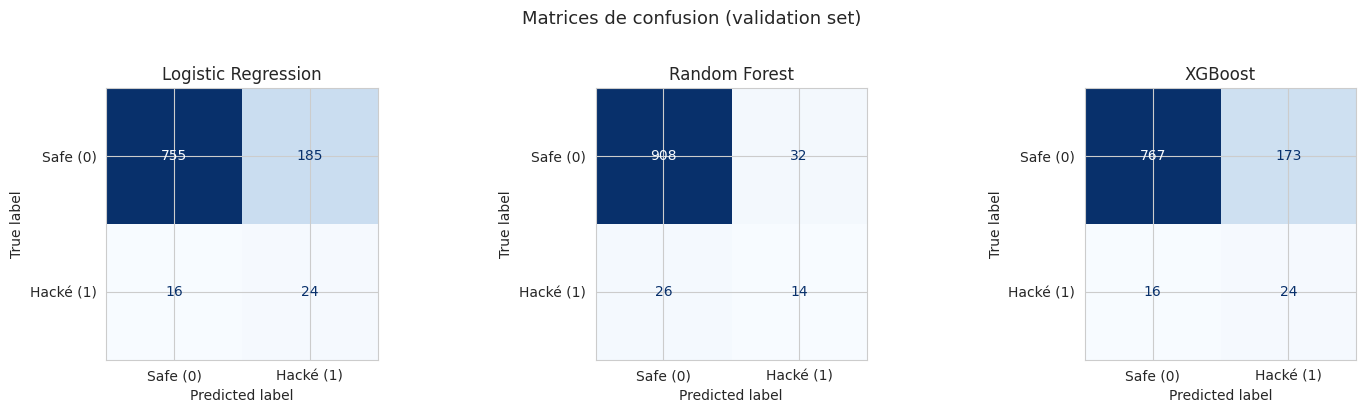

Lecture :
  • Bas-gauche (FN) : protocoles hackés non détectés → à minimiser !
  • Haut-droite (FP) : protocoles safe signalés comme risqués → acceptable


In [54]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, gs) in zip(axes, models.items()):
    y_pred = gs.predict(X_val)
    cm = confusion_matrix(y_val, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Safe (0)', 'Hacké (1)'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name)

fig.suptitle('Matrices de confusion (validation set)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print('Lecture :')
print('  • Bas-gauche (FN) : protocoles hackés non détectés → à minimiser !')
print('  • Haut-droite (FP) : protocoles safe signalés comme risqués → acceptable')


### 7.3 Courbe ROC et AUC

> **ROC** (Receiver Operating Characteristic) : courbe qui trace le Recall (TPR) vs le taux de faux positifs (FPR) pour tous les seuils possibles.  
> **AUC** : aire sous la courbe ROC. Plus elle est proche de 1, meilleur est le modèle.  
> Un modèle aléatoire a un AUC = 0.5 (diagonale).

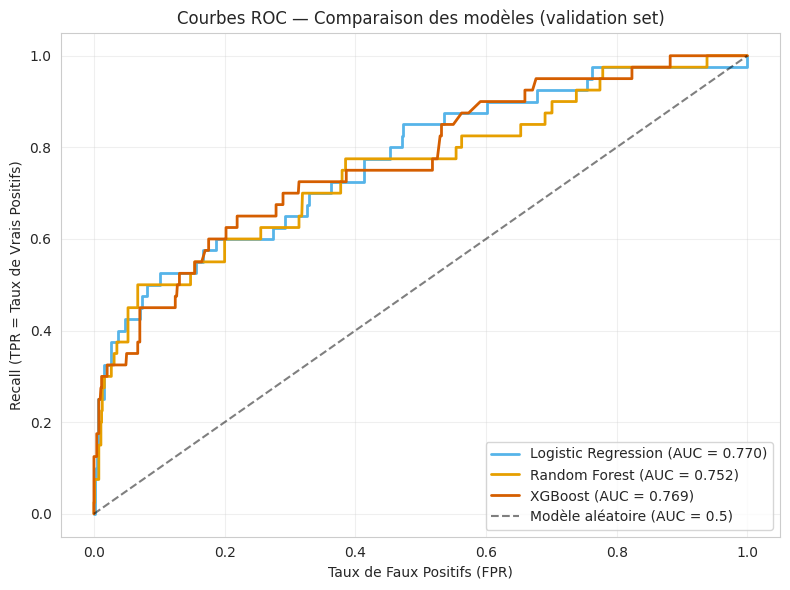

Lecture :
  • Plus la courbe est proche du coin haut-gauche, meilleur est le modèle
  • AUC > 0.8 = bon modèle ; AUC > 0.9 = excellent
  • L'AUC est indépendante du seuil de décision (0.5 par défaut)


In [55]:
fig, ax = plt.subplots(figsize=(8, 6))

colors = ['#56B4E9', '#E69F00', '#D55E00']  # Okabe-Ito
for (name, gs), color in zip(models.items(), colors):
    y_proba = gs.predict_proba(X_val)[:, 1]
    fpr, tpr, _ = roc_curve(y_val, y_proba)
    auc = roc_auc_score(y_val, y_proba)
    ax.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC = {auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Modèle aléatoire (AUC = 0.5)')
ax.set_xlabel('Taux de Faux Positifs (FPR)')
ax.set_ylabel('Recall (TPR = Taux de Vrais Positifs)')
ax.set_title('Courbes ROC — Comparaison des modèles (validation set)')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print('Lecture :')
print('  • Plus la courbe est proche du coin haut-gauche, meilleur est le modèle')
print('  • AUC > 0.8 = bon modèle ; AUC > 0.9 = excellent')
print('  • L\'AUC est indépendante du seuil de décision (0.5 par défaut)')

### 7.4 Courbe Precision-Recall (plus adaptée aux données déséquilibrées)

> La courbe ROC peut être trop optimiste avec des données très déséquilibrées.  
> La courbe **Precision-Recall** est plus informative : elle montre le tradeoff entre détecter des hacks (Recall) et éviter les fausses alertes (Précision).

**Comment lire une courbe Precision-Recall ?**

Une courbe PR **part toujours du point (Recall=0, Précision=1)** : au seuil maximum, le modèle ne prédit qu'un seul protocole hacké et il a raison.

Au fur et à mesure qu'on **baisse le seuil**, on détecte plus de hacks (Recall monte) mais on génère aussi plus de fausses alertes (Précision descend).

Un **bon modèle** maintient une précision élevée même à haut recall => la courbe reste haute dans le graphe.  
Un **modèle qui peine** (comme ici, avec un déséquilibre de ~3%) voit sa précision chuter rapidement => la courbe descend en zigzag vers le bas-droit.

L'**AP score** (Average Precision = aire sous la courbe) mesure cette qualité globale.  
Comparer l'AP à la baseline (~3%) indique combien le modèle est meilleur qu'un tirage aléatoire.

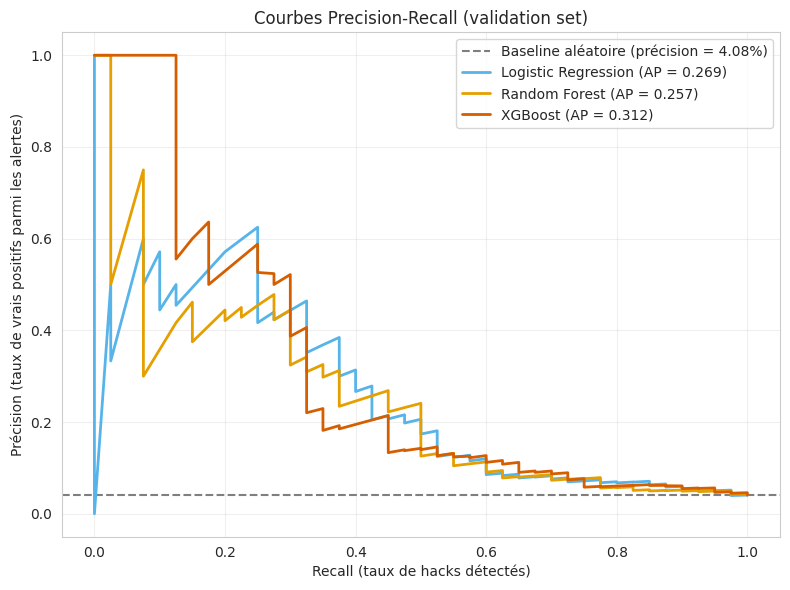

Lecture :
  • Les courbes descendent — cela reflète la difficulté du problème :
    détecter des hacks rares (4.1%) avec des features imparfaites.
  • Un bon modèle reste le plus haut possible : la précision chute lentement.
  • L'AP score (aire sous la courbe) mesure à quel point on fait mieux qu'un
    tirage aléatoire (baseline = 4.1%).

→ Meilleur modèle sur AP : XGBoost (AP = 0.312)
  Soit 7.6x mieux que la baseline aléatoire (AP = 0.041).

  Pour le Risk Scanner, on accepte une précision basse (+ fausses alertes)
  pour maximiser le Recall (ne rater aucun hack réel).


In [56]:
fig, ax = plt.subplots(figsize=(8, 6))

# Baseline : modèle aléatoire → précision = proportion de positifs
baseline_pr = y_val.mean()
ax.axhline(y=baseline_pr, color='k', linestyle='--', alpha=0.5,
           label=f'Baseline aléatoire (précision = {baseline_pr:.2%})')

ap_scores = {}
for (name, gs), color in zip(models.items(), colors):
    y_proba = gs.predict_proba(X_val)[:, 1]
    precision, recall, _ = precision_recall_curve(y_val, y_proba)
    ap = average_precision_score(y_val, y_proba)
    ap_scores[name] = ap
    ax.plot(recall, precision, color=color, lw=2, label=f'{name} (AP = {ap:.3f})')

ax.set_xlabel('Recall (taux de hacks détectés)')
ax.set_ylabel('Précision (taux de vrais positifs parmi les alertes)')
ax.set_title('Courbes Precision-Recall (validation set)')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

best_ap_name = max(ap_scores, key=ap_scores.get)
best_ap_val  = ap_scores[best_ap_name]
lift = best_ap_val / baseline_pr if baseline_pr > 0 else float('inf')

print('Lecture :')
print('  • Les courbes descendent — cela reflète la difficulté du problème :')
print(f'    détecter des hacks rares ({baseline_pr:.1%}) avec des features imparfaites.')
print('  • Un bon modèle reste le plus haut possible : la précision chute lentement.')
print(f"  • L'AP score (aire sous la courbe) mesure à quel point on fait mieux qu'un")
print(f'    tirage aléatoire (baseline = {baseline_pr:.1%}).')
print()
print(f'→ Meilleur modèle sur AP : {best_ap_name} (AP = {best_ap_val:.3f})')
print(f'  Soit {lift:.1f}x mieux que la baseline aléatoire (AP = {baseline_pr:.3f}).')
print()
print('  Pour le Risk Scanner, on accepte une précision basse (+ fausses alertes)')
print('  pour maximiser le Recall (ne rater aucun hack réel).')

## 8. Threshold Tuning — Analyse binaire secondaire

Par défaut, sklearn classe un protocole comme « hacké » si `predict_proba > 0.5`.  
On peut abaisser ce seuil (ex. `0.3`) pour maximiser le Recall au détriment de la Précision.

> **Hiérarchie d'usage** :
> 1. **Usage principal** : ranking protocol-level par `risk_score`, piloté par `Recall@k` / `Lift@k`.
> 2. **Usage secondaire** : seuil `0.3` comme mode de triage max-recall quand on veut convertir le score en alerte binaire.

**Le tradeoff** : baisser le seuil → plus de Recall, moins de Précision (plus de fausses alertes).

In [57]:
# On prend le meilleur modèle selon ROC-AUC sur validation
best_name = max(models.items(), key=lambda x: roc_auc_score(y_val, x[1].predict_proba(X_val)[:, 1]))[0]
best_model = models[best_name]
y_proba_val = best_model.predict_proba(X_val)[:, 1]

print(f'Meilleur modèle (ROC-AUC) : {best_name}')

thresholds = np.arange(0.1, 0.9, 0.05)
threshold_results = []

for t in thresholds:
    y_pred_t = (y_proba_val >= t).astype(int)
    threshold_results.append({
        'Seuil':      t,
        'Recall':     recall_score(y_val, y_pred_t, zero_division=0),
        'Précision':  precision_score(y_val, y_pred_t, zero_division=0),
        'F1':         f1_score(y_val, y_pred_t, zero_division=0),
    })

df_thresholds = pd.DataFrame(threshold_results)

Meilleur modèle (ROC-AUC) : Logistic Regression


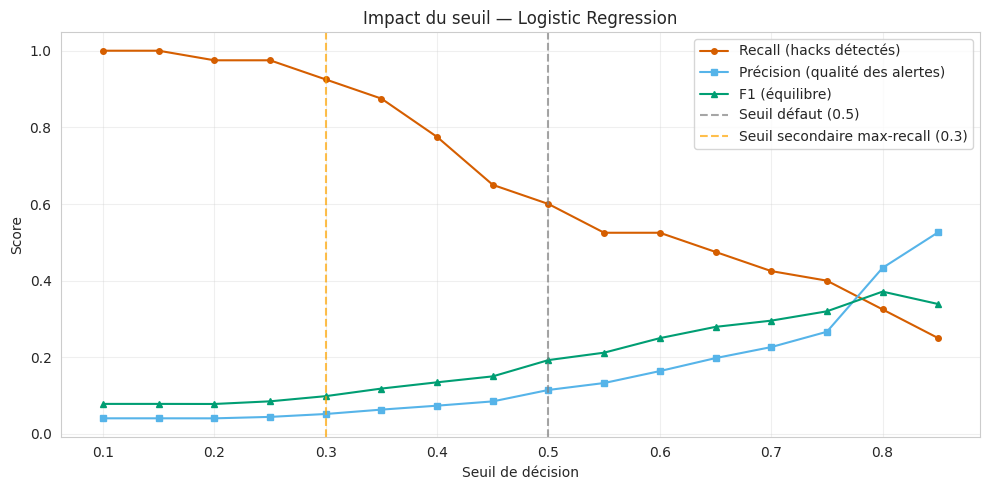

Interprétation :
  • Mode principal : classer les protocoles par risk_score (ranking top-k)
  • Seuil 0.3 : mode secondaire de triage max-recall → plus d'alertes, moins de hacks manqués
  • Seuil haut (0.7) : moins d'alertes, mais davantage de hacks ratés
  → Seuil secondaire de référence : 0.3


In [58]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(df_thresholds['Seuil'], df_thresholds['Recall'],    color='#D55E00', marker='o', ms=4, linestyle='-', label='Recall (hacks détectés)')
ax.plot(df_thresholds['Seuil'], df_thresholds['Précision'], color='#56B4E9', marker='s', ms=4, linestyle='-', label='Précision (qualité des alertes)')
ax.plot(df_thresholds['Seuil'], df_thresholds['F1'],        color='#009E73', marker='^', ms=4, linestyle='-', label='F1 (équilibre)')

ax.axvline(x=0.5, color='gray', linestyle='--', alpha=0.7, label='Seuil défaut (0.5)')
ax.axvline(x=0.3, color='orange', linestyle='--', alpha=0.7, label='Seuil secondaire max-recall (0.3)')

ax.set_xlabel('Seuil de décision')
ax.set_ylabel('Score')
ax.set_title(f'Impact du seuil — {best_name}')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print('Interprétation :')
print('  • Mode principal : classer les protocoles par risk_score (ranking top-k)')
print('  • Seuil 0.3 : mode secondaire de triage max-recall → plus d\'alertes, moins de hacks manqués')
print('  • Seuil haut (0.7) : moins d\'alertes, mais davantage de hacks ratés')
print('  → Seuil secondaire de référence : 0.3')

In [59]:
# Impact du seuil sur quelques valeurs
key_thresholds = [0.3, 0.5, 0.7]
print(f'Impact du seuil pour {best_name} :\n')
print(f'{"Seuil":>8} | {"Recall":>8} | {"Précision":>10} | {"F1":>8}')
print('-' * 45)
for t in key_thresholds:
    y_pred_t = (y_proba_val >= t).astype(int)
    r = recall_score(y_val, y_pred_t, zero_division=0)
    p = precision_score(y_val, y_pred_t, zero_division=0)
    f = f1_score(y_val, y_pred_t, zero_division=0)
    marker = ' ← seuil secondaire max-recall' if t == 0.3 else ('  ← défaut sklearn' if t == 0.5 else '')
    print(f'{t:>8.1f} | {r:>8.3f} | {p:>10.3f} | {f:>8.3f}{marker}')

print()
r_dict = {}
for t in key_thresholds:
    y_pred_t = (y_proba_val >= t).astype(int)
    r_dict[t] = {
        'recall': recall_score(y_val, y_pred_t, zero_division=0),
        'precision': precision_score(y_val, y_pred_t, zero_division=0),
    }

gain_recall = r_dict[0.3]['recall'] - r_dict[0.5]['recall']
cost_prec = r_dict[0.5]['precision'] - r_dict[0.3]['precision']
prec_05 = r_dict[0.5]['precision']
prec_03 = r_dict[0.3]['precision']
alerts_per_hack_05 = round(1 / prec_05) if prec_05 > 0 else float('inf')
alerts_per_hack_03 = round(1 / prec_03) if prec_03 > 0 else float('inf')

print(f'Interprétation du tradeoff seuil 0.5 → 0.3 :')
print(f'  Recall : {r_dict[0.5]["recall"]:.0%} → {r_dict[0.3]["recall"]:.0%}  (+{gain_recall:.0%} de hacks détectés)')
print(f'  Précision : {prec_05:.1%} → {prec_03:.1%}  (-{cost_prec:.1%} en valeur absolue, soit -{cost_prec/prec_05:.0%} relative)')
print()
print(f'  En termes concrets :')
print(f'  • Seuil 0.5 : 1 vrai hack pour ~{alerts_per_hack_05} alertes — vérification humaine raisonnable')
print(f'  • Seuil 0.3 : 1 vrai hack pour ~{alerts_per_hack_03} alertes — beaucoup plus de faux positifs')
print()
if r_dict[0.3]['recall'] >= 0.99:
    print(f'  Note : Recall≈100% au seuil 0.3 signifie que le modèle flagge ~{alerts_per_hack_03}× plus de protocoles')
    print(f'  qu\'il n\'y a de vrais hacks. En production, à ajuster selon la capacité d\'investigation.')
print('  → Ce seuil sert surtout à un mode de triage secondaire.')
print("    L'usage métier recommandé reste le ranking top-k par risk_score (section 10).")

Impact du seuil pour Logistic Regression :

   Seuil |   Recall |  Précision |       F1
---------------------------------------------
     0.3 |    0.925 |      0.052 |    0.099 ← seuil secondaire max-recall
     0.5 |    0.600 |      0.115 |    0.193  ← défaut sklearn
     0.7 |    0.425 |      0.227 |    0.296

Interprétation du tradeoff seuil 0.5 → 0.3 :
  Recall : 60% → 92%  (+33% de hacks détectés)
  Précision : 11.5% → 5.2%  (-6.3% en valeur absolue, soit -55% relative)

  En termes concrets :
  • Seuil 0.5 : 1 vrai hack pour ~9 alertes — vérification humaine raisonnable
  • Seuil 0.3 : 1 vrai hack pour ~19 alertes — beaucoup plus de faux positifs

  → Ce seuil sert surtout à un mode de triage secondaire.
    L'usage métier recommandé reste le ranking top-k par risk_score (section 10).


## 9. Interprétabilité exploratoire — RF/XGB & SHAP

Les visualisations ci-dessous servent à comprendre les signaux captés par les modèles d'arbres comparés.
La lecture du **modèle final effectivement retenu** est traitée séparément en section 10.2, de façon dynamique selon le meilleur modèle de l'exécution.

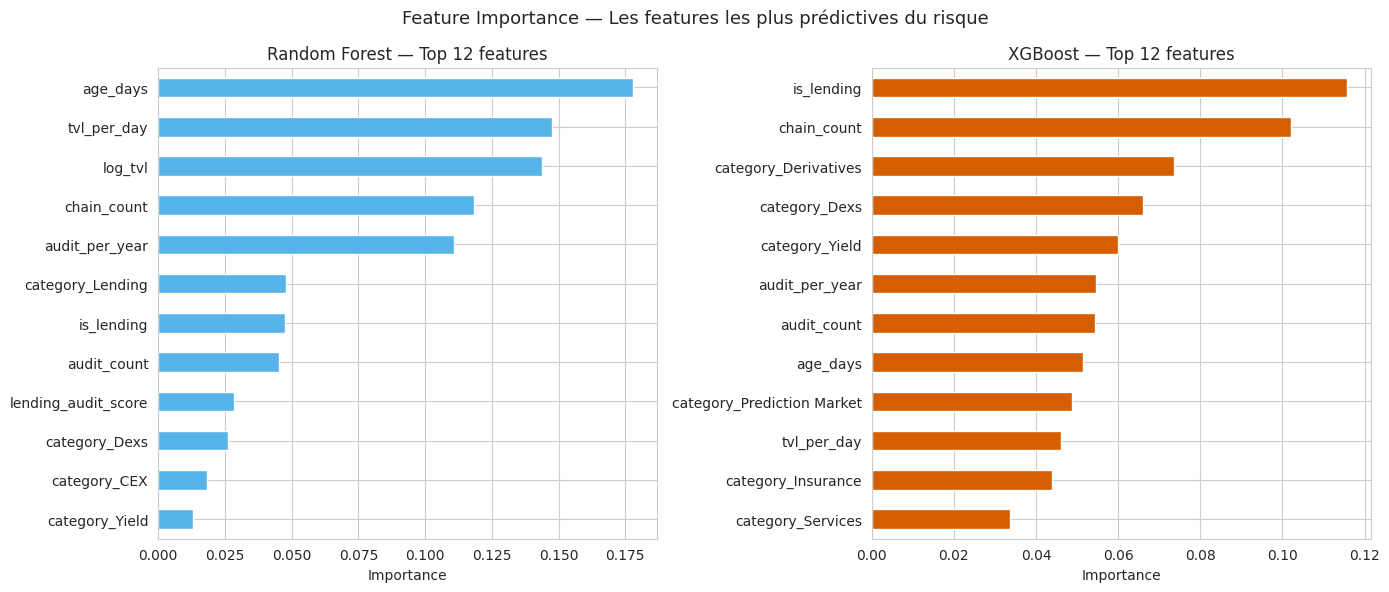

Top 10 features selon Random Forest :
  0.1779  age_days                                 → Âge — protocole établi mais exposé = cible mature et lucrative
  0.1474  tvl_per_day                              → TVL/âge — fort TVL récent = honey pot non encore testé
  0.1438  log_tvl                                  → Log TVL — TVL élevé = cible financièrement attractive
  0.1185  chain_count                              → Nb de chaînes — plus de bridges = plus de vecteurs d'attaque
  0.1108  audit_per_year                           → Audits/an — fréquence des revues de sécurité dans le temps
  0.0481  category_Lending                         → Catégorie encodée — le type de protocole influence le vecteur d'attaque
  0.0474  is_lending                               → Est un Lending — exposé aux flash loan attacks
  0.0453  audit_count                              → Nb d'audits — chaque audit réduit les vulnérabilités connues
  0.0283  lending_audit_score                      → Lending × aud

In [60]:
# Récupérer les noms des features après OneHotEncoding
def get_feature_names(preprocessor, num_features, bin_features, cat_features):
    cat_ohe = preprocessor.named_transformers_['cat']['ohe']
    cat_names = cat_ohe.get_feature_names_out(cat_features).tolist()
    return num_features + bin_features + cat_names

# Fit du preprocessor sur X_train pour récupérer les noms
preprocessor_fit = gs_rf.best_estimator_.named_steps['preprocessor']
feature_names = get_feature_names(preprocessor_fit, FEATURES_NUM, FEATURES_BIN, FEATURES_CAT)

# Feature importances Random Forest
rf_model = gs_rf.best_estimator_.named_steps['model']
importances_rf = pd.Series(rf_model.feature_importances_, index=feature_names).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

importances_rf.head(12).sort_values().plot.barh(ax=axes[0], color='#56B4E9')  # Okabe-Ito
axes[0].set_title('Random Forest — Top 12 features')
axes[0].set_xlabel('Importance')

# Feature importances XGBoost
xgb_model = gs_xgb.best_estimator_.named_steps['model']
preprocessor_xgb = gs_xgb.best_estimator_.named_steps['preprocessor']
feature_names_xgb = get_feature_names(preprocessor_xgb, FEATURES_NUM, FEATURES_BIN, FEATURES_CAT)
importances_xgb = pd.Series(xgb_model.feature_importances_, index=feature_names_xgb).sort_values(ascending=False)

importances_xgb.head(12).sort_values().plot.barh(ax=axes[1], color='#D55E00')  # Okabe-Ito
axes[1].set_title('XGBoost — Top 12 features')
axes[1].set_xlabel('Importance')

plt.suptitle('Feature Importance — Les features les plus prédictives du risque', fontsize=13)
plt.tight_layout()
plt.show()

# Lookup table complète : toutes les features possibles + leurs features OHE (préfixe)
FEATURE_MEANINGS = {
    'log_tvl':          'Log TVL — TVL élevé = cible financièrement attractive',
    'age_days':         'Âge — protocole établi mais exposé = cible mature et lucrative',
    'tvl_per_day':      'TVL/âge — fort TVL récent = honey pot non encore testé',
    'audit_count':      "Nb d'audits — chaque audit réduit les vulnérabilités connues",
    'chain_count':      "Nb de chaînes — plus de bridges = plus de vecteurs d'attaque",
    'audit_per_year':   'Audits/an — fréquence des revues de sécurité dans le temps',
    'lending_audit_score': 'Lending × audits — signal structurel (gros protocoles = plus audités = plus ciblés)',
    'has_audit':        'A un audit (binaire) — absence = exposition maximale aux vulnérabilités',
    'is_multichain':    "Multi-chain — surface d'attaque élargie via les bridges",
    'is_dex':           'Est un DEX — exposé aux price manipulation attacks',
    'is_lending':       'Est un Lending — exposé aux flash loan attacks',
    'is_bridge':        "Est un Bridge — vecteur #1 des hacks DeFi (pertes cumulées majeures)",
    'category':         "Catégorie encodée — le type de protocole influence le vecteur d'attaque",
    'audit_status':     "Statut d'audit (Rekt News) — 'Unaudited' = aucune revue de sécurité externe",
}

print('Top 10 features selon Random Forest :')
for feat, importance in importances_rf.head(10).items():
    # Match sur préfixe pour gérer les suffixes OHE (ex: category_Dexes, audit_status_Unaudited)
    meaning = next((v for k, v in FEATURE_MEANINGS.items() if feat.startswith(k)), f'Feature encodée : {feat}')
    print(f'  {importance:.4f}  {feat:<40} → {meaning}')

print()
print('Top 10 features selon XGBoost :')
for feat, importance in importances_xgb.head(10).items():
    meaning = next((v for k, v in FEATURE_MEANINGS.items() if feat.startswith(k)), f'Feature encodée : {feat}')
    print(f'  {importance:.4f}  {feat:<40} → {meaning}')


### 9.1 SHAP Values — Comprendre chaque prédiction individuelle (lecture exploratoire sur XGBoost)

> **SHAP** (SHapley Additive exPlanations) : pour chaque protocole, SHAP indique la contribution de chaque feature à la prédiction.  
> C'est la différence avec la feature importance globale : SHAP est **local** (par protocole).
>
> **Lecture du beeswarm plot** :
> - Chaque point = un protocole
> - Couleur : rouge = valeur haute de la feature, bleu = valeur basse
> - Position X : impact sur la prédiction (droite = augmente le risque)
>
> Cette section reste **complémentaire** : elle éclaire un modèle comparatif (XGBoost), pas le modèle final déployé.

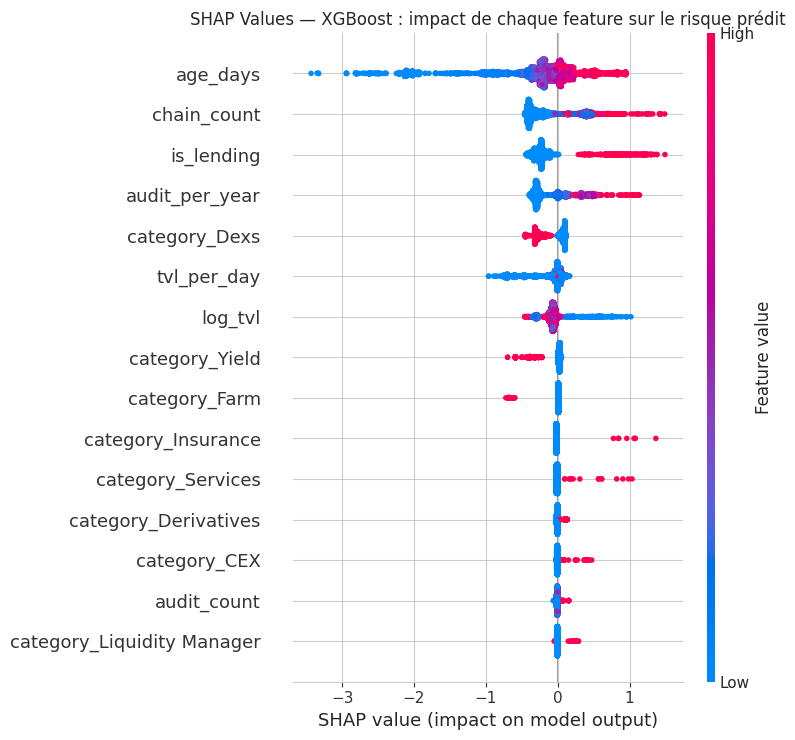

Lecture du beeswarm SHAP :
  • Chaque ligne = une feature (triée par importance globale, top en haut)
  • Chaque point = un protocole — sa position X = impact sur le score de risque
  • Couleur : rouge = valeur élevée de la feature, bleu = valeur faible
  • X > 0 : la feature pousse le score vers "risqué"  |  X < 0 : vers "safe"

Top 5 features selon XGBoost (SHAP) :
  1. is_lending
     → lending (rouge, X>0) = gros dépôts exposés aux flash loan attacks
  2. chain_count
     → multi-chain (rouge, X>0) = surface d'attaque élargie via les bridges
  3. category_Derivatives — la catégorie "Derivatives" a un profil de risque distinctif dans les données
  4. category_Dexs — la catégorie "Dexs" a un profil de risque distinctif dans les données
  5. category_Yield — la catégorie "Yield" a un profil de risque distinctif dans les données

Observation clé : lending_audit_score (r=+0.172, signal #1 en section 3) est moins visible
dans SHAP car XGBoost capture l'interaction is_lending × audit_coun

In [61]:
# SHAP sur XGBoost (TreeExplainer — rapide pour les modèles à base d'arbres)
X_train_transformed = preprocessor_xgb.transform(X_train)

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_train_transformed)

# Beeswarm plot
plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_values,
    X_train_transformed,
    feature_names=feature_names_xgb,
    max_display=15,
    show=False
)
plt.title('SHAP Values — XGBoost : impact de chaque feature sur le risque prédit', fontsize=12)
plt.tight_layout()
plt.show()

print('Lecture du beeswarm SHAP :')
print('  • Chaque ligne = une feature (triée par importance globale, top en haut)')
print('  • Chaque point = un protocole — sa position X = impact sur le score de risque')
print('  • Couleur : rouge = valeur élevée de la feature, bleu = valeur faible')
print('  • X > 0 : la feature pousse le score vers "risqué"  |  X < 0 : vers "safe"')
print()

# Interprétation dynamique des top features
top5 = importances_xgb.head(5).index.tolist()
SHAP_INTERPRETATIONS = {
    'age_days':             ('âge élevé (rouge, X>0) = protocole établi ciblé pour son TVL accumulé',
                             'jeune protocole (bleu, X<0) = moins attractif car encore en développement'),
    'chain_count':          ('multi-chain (rouge, X>0) = surface d\'attaque élargie via les bridges',
                             'mono-chain (bleu, X<0) = vecteurs d\'attaque plus limités'),
    'is_lending':           ('lending (rouge, X>0) = gros dépôts exposés aux flash loan attacks',
                             'non-lending (bleu, X<0) = moins de liquidité concentrée'),
    'audit_per_year':       ('audits fréquents (rouge) peuvent aller dans les deux sens : protocoles sérieux ET ciblés',
                             'aucun audit (bleu) → modèle incertain — absence d\'information'),
    'log_tvl':              ('TVL élevé (rouge, X>0) = cible financièrement attractive',
                             'petit TVL (bleu, X<0) = moins lucratif à hacker'),
    'lending_audit_score':  ('lending audité (rouge, X>0) = protocole établi avec dépôts importants = cible prioritaire',
                             'note 0 = non-lending ou lending non audité'),
    'tvl_per_day':          ('TVL/âge élevé (rouge) = honey pot récent — TVL important accumulé rapidement',
                             'faible ratio = protocole qui a grandi lentement ou vieillit'),
}

print('Top 5 features selon XGBoost (SHAP) :')
for rank, feat in enumerate(top5, 1):
    base_feat = next((k for k in SHAP_INTERPRETATIONS if feat.startswith(k)), None)
    if base_feat:
        high_interp, low_interp = SHAP_INTERPRETATIONS[base_feat]
        print(f'  {rank}. {feat}')
        print(f'     → {high_interp}')
    else:
        cat = feat.replace('category_', '')
        print(f'  {rank}. {feat} — la catégorie "{cat}" a un profil de risque distinctif dans les données')

print()
print('Observation clé : lending_audit_score (r=+0.172, signal #1 en section 3) est moins visible')
print('dans SHAP car XGBoost capture l\'interaction is_lending × audit_count via ses arbres directement,')
print('rendant la feature composite partiellement redondante avec is_lending et audit_per_year séparés.')

---
## ⚠️ Limites du modèle

| Limite | Description |
|--------|-------------|
| **Biais temporel** | Les features (TVL, audits, chains) sont des snapshots 2026 pour des hacks survenus entre 2016–2025. Un protocole hacké peut avoir un TVL effondré post-hack. |
| **Corrélation ≠ causalité** | Le modèle apprend des profils historiques. `lending_audit_score` capte un effet de taille (gros protocoles = plus audités = plus ciblés), pas un mécanisme causal. |
| **Dataset incident-level** | Un protocole multi-incidents apparaît plusieurs fois en train. Les protocoles multi-incidents sont légèrement surpondérés — noté comme piste d'amélioration future (déduplication ou pondération par protocole). |
| **Recall élevé / précision faible** | Le modèle est optimisé pour le triage (max-recall). En production, toute alerte doit être validée par un humain. |
| **Dataset déséquilibré** | 3.3% de positifs — les métriques doivent être lues en contexte (ROC-AUC, Recall@k, Lift@k plutôt qu'Accuracy). |
| **Biais de mesure (CEX)** | Les CEX (Binance, Bybit…) remontent avec des scores élevés car `audit_count` est une feature DeFi-native : elle capte les audits de smart contracts mais pas les certifications CEX. Pour un CEX, `audit_count = 0` signifie *donnée manquante*, pas *absence d'audit*. Ce biais est structurel — il provient du dataset source, pas du modèle. |


> **Note sur les CEX** : ce biais ne remet pas en cause le ranking — les CEX sont effectivement des cibles majeures historiquement (Bybit 1.4Md$, Mt. Gox, FTX). Le modèle « a raison pour les mauvaises raisons » : il les flagge à risque élevé, et ils méritent effectivement une attention accrue, mais *parce qu'ils sont de gros targets*, pas parce que `audit_count = 0` reflète un vrai manque d'audit. Le problème n'est pas le ranking — c'est l'**interprétation causale** de la feature. En production, un pipeline CEX distinct avec des features adaptées (preuve de réserves, insurance fund, statut réglementaire) serait nécessaire pour une explication défendable.

> **Usage recommandé** : utiliser le `risk_score` comme outil de **ranking et de priorisation**. Les X% de protocoles avec le score le plus élevé concentrent une part disproportionnée des hacks documentés (cf. courbe Lift@k ci-dessous).


## 10 Évaluation finale sur le test set

> **Usage principal retenu** : ranking protocol-level (`Recall@k`, `Lift@k`) pour prioriser les revues.
> **Usage secondaire** : classification binaire au seuil `0.3` pour un mode max-recall, plus agressif en fausses alertes.

**Maintenant seulement** on touche au test set : il était invisible jusqu'ici.  
On refit d'abord le meilleur modèle sur train+val, puis on évalue sur test.

**Compromis méthodologique** : l'entraînement est à granularité *incident-level* (un protocole multi-incidents apparaît plusieurs fois → plus de signal). L'évaluation finale du ranking est réalisée à *protocol-level* : on agrège par protocole (max `risk_score`) pour obtenir un classement d'une ligne par protocole. C'est plus cohérent avec l'usage métier.

=== USAGE PRINCIPAL — Ranking protocol-level (974 protocoles uniques | 25 hackés) ===
  Top k% |  N alertes |   Recall@k |  Precision@k |     Lift
------------------------------------------------------------
      1% |          9 |      8.0% |       22.2% |     8.7x
      2% |         19 |      8.0% |       10.5% |     4.1x
      5% |         48 |     32.0% |       16.7% |     6.5x
     10% |         97 |     44.0% |       11.3% |     4.4x
     15% |        146 |     52.0% |        8.9% |     3.5x
     20% |        194 |     56.0% |        7.2% |     2.8x


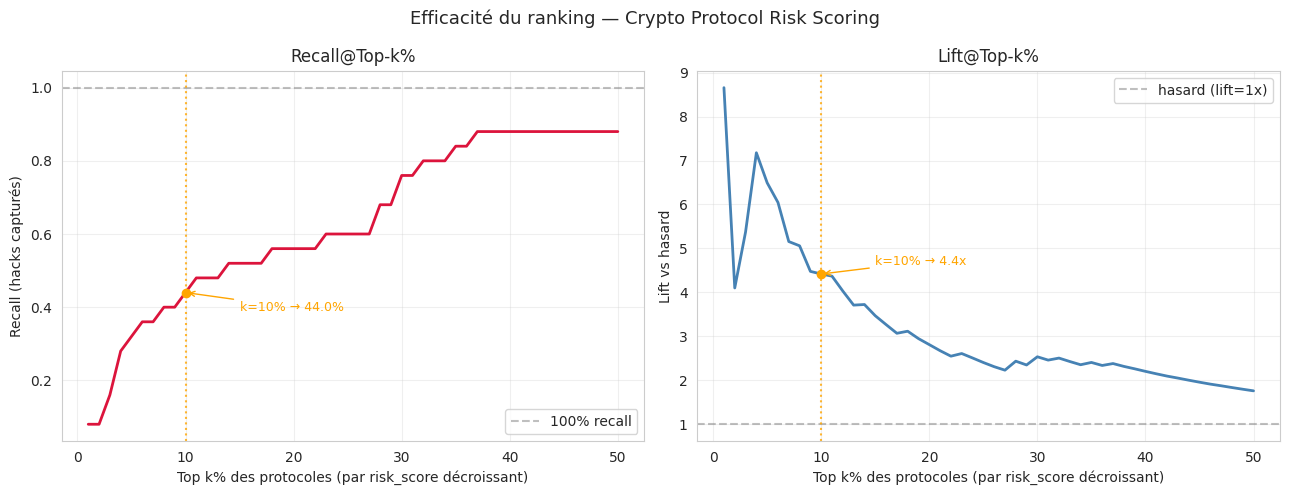


Conclusion métier : dans le top 10% des protocoles scorés (97 protocoles),
  on retrouve 44.0% des hacks documentés du test set, soit 4.4x mieux qu'un tirage aléatoire.

=== LECTURE SECONDAIRE — Classification binaire sur le test set (Logistic Regression, seuil=0.3) ===
              precision    recall  f1-score   support

        Safe       0.99      0.37      0.54       949
       Hacké       0.04      0.92      0.07        26

    accuracy                           0.38       975
   macro avg       0.52      0.64      0.30       975
weighted avg       0.97      0.38      0.52       975

ROC-AUC : 0.7925

Lecture du rapport de classification :
  • Support (Hacké) : nombre de protocoles hackés dans le test set (données réelles uniquement)
  • Précision (Hacké) : sur tous les protocoles signalés risqués, quelle proportion l'est vraiment ?
  • Recall (Hacké)   : sur tous les hacks réels du test set, combien a-t-on détectés ?
  • F1 (Hacké)       : équilibre Précision × Recall — synthè

In [62]:
# Refit du meilleur modèle sur train + val
X_trainval_full = pd.concat([X_train, X_val])
y_trainval_full = pd.concat([y_train, y_val])

# Extraire la pipeline avec les meilleurs hyperparamètres (pas le GridSearchCV)
from sklearn.base import clone
final_model = clone(best_model.best_estimator_)
final_model.fit(X_trainval_full, y_trainval_full)

# Scores sur le test set
y_proba_test = final_model.predict_proba(X_test)[:, 1]
THRESHOLD = 0.3  # seuil secondaire max-recall
y_pred_test = (y_proba_test >= THRESHOLD).astype(int)

# ── Ranking protocol-level : usage principal ───────────────────────────────
df_test_scored = X_test.copy()
df_test_scored['risk_score'] = y_proba_test
df_test_scored['hacked'] = y_test.values
df_test_scored['protocol'] = df.iloc[test_idx]['protocol'].values

df_proto = (
    df_test_scored
    .groupby('protocol')
    .agg(risk_score=('risk_score', 'max'), hacked=('hacked', 'max'))
    .reset_index()
    .sort_values('risk_score', ascending=False)
)

total_hacks = df_proto['hacked'].sum()
base_rate = df_proto['hacked'].mean()

print(f'=== USAGE PRINCIPAL — Ranking protocol-level ({len(df_proto)} protocoles uniques | {total_hacks} hackés) ===')
print(f'{"Top k%":>8} | {"N alertes":>10} | {"Recall@k":>10} | {"Precision@k":>12} | {"Lift":>8}')
print('-' * 60)
k_values = [1, 2, 5, 10, 15, 20]
for k in k_values:
    n_top = max(1, int(len(df_proto) * k / 100))
    top_k = df_proto.head(n_top)
    recall_k = top_k['hacked'].sum() / total_hacks if total_hacks > 0 else 0
    prec_k = top_k['hacked'].mean()
    lift_k = prec_k / base_rate if base_rate > 0 else 0
    print(f'{k:>7}% | {n_top:>10} | {recall_k:>9.1%} | {prec_k:>11.1%} | {lift_k:>7.1f}x')

ks = range(1, 51)
recalls, lifts = [], []
for k in ks:
    n_top = max(1, int(len(df_proto) * k / 100))
    top_k = df_proto.head(n_top)
    recall_k = top_k['hacked'].sum() / total_hacks if total_hacks > 0 else 0
    prec_k = top_k['hacked'].mean()
    recalls.append(recall_k)
    lifts.append(prec_k / base_rate if base_rate > 0 else 0)

top10_n = max(1, int(len(df_proto) * 10 / 100))
top10_rec = df_proto.head(top10_n)['hacked'].sum() / total_hacks if total_hacks > 0 else 0
top10_lift = df_proto.head(top10_n)['hacked'].mean() / base_rate if base_rate > 0 else 0

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(list(ks), recalls, color='crimson', linewidth=2)
axes[0].axhline(1.0, linestyle='--', color='gray', alpha=0.5, label='100% recall')
axes[0].axvline(10, linestyle=':', color='orange', alpha=0.8)
axes[0].plot(10, top10_rec, 'o', color='orange', zorder=5)
axes[0].annotate(f'k=10% → {top10_rec:.1%}',
                 xy=(10, top10_rec), xytext=(15, top10_rec - 0.05),
                 arrowprops=dict(arrowstyle='->', color='orange'),
                 fontsize=9, color='orange')
axes[0].set(xlabel="Top k% des protocoles (par risk_score décroissant)",
            ylabel="Recall (hacks capturés)", title="Recall@Top-k%")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(list(ks), lifts, color='steelblue', linewidth=2)
axes[1].axhline(1.0, linestyle='--', color='gray', alpha=0.5, label='hasard (lift=1x)')
axes[1].axvline(10, linestyle=':', color='orange', alpha=0.8)
axes[1].plot(10, top10_lift, 'o', color='orange', zorder=5)
axes[1].annotate(f'k=10% → {top10_lift:.1f}x',
                 xy=(10, top10_lift), xytext=(15, top10_lift + 0.2),
                 arrowprops=dict(arrowstyle='->', color='orange'),
                 fontsize=9, color='orange')
axes[1].set(xlabel="Top k% des protocoles (par risk_score décroissant)",
            ylabel="Lift vs hasard", title="Lift@Top-k%")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle("Efficacité du ranking — Crypto Protocol Risk Scoring", fontsize=13)
plt.tight_layout()
plt.show()

print(f'\nConclusion métier : dans le top 10% des protocoles scorés ({top10_n} protocoles),')
print(f'  on retrouve {top10_rec:.1%} des hacks documentés du test set, soit {top10_lift:.1f}x mieux qu\'un tirage aléatoire.')

# ── Classification binaire : lecture secondaire ────────────────────────────
auc_test = roc_auc_score(y_test, y_proba_test)
print(f'\n=== LECTURE SECONDAIRE — Classification binaire sur le test set ({best_name}, seuil={THRESHOLD}) ===')
print(classification_report(y_test, y_pred_test, target_names=['Safe', 'Hacké']))
print(f'ROC-AUC : {auc_test:.4f}')
print()
print('Lecture du rapport de classification :')
print('  • Support (Hacké) : nombre de protocoles hackés dans le test set (données réelles uniquement)')
print('  • Précision (Hacké) : sur tous les protocoles signalés risqués, quelle proportion l\'est vraiment ?')
print('  • Recall (Hacké)   : sur tous les hacks réels du test set, combien a-t-on détectés ?')
print('  • F1 (Hacké)       : équilibre Précision × Recall — synthèse en un chiffre')
auc_label = 'excellent' if auc_test > 0.9 else ('bon' if auc_test > 0.8 else ('acceptable' if auc_test > 0.7 else 'à améliorer'))
print(f'  • ROC-AUC = {auc_test:.4f} → {auc_label} (>0.9 = excellent, >0.8 = bon, >0.7 = acceptable)')
print()
print('Ces métriques binaires servent surtout à illustrer le compromis de triage au seuil 0.3.')
print("Le mode d'usage recommandé du produit reste le ranking top-k présenté ci-dessus.")

### 10.1 Lecture du modèle final retenu

On interprète ici **le modèle effectivement retenu et refitté en section 10.1**.

- Si le modèle final est **linéaire** (`Logistic Regression`), on lit ses coefficients et leurs **odds ratios**.
- Si le modèle final est **arboré** (`Random Forest` / `XGBoost`), on lit ses **feature importances**.

> Cette section reste donc alignée avec le modèle réellement sauvegardé en section 10.4, même si le meilleur modèle change entre deux exécutions du notebook.

In [63]:
# Interprétation du modèle final effectivement retenu
final_preprocessor = final_model.named_steps['preprocessor']
final_estimator = final_model.named_steps['model']
feature_names_final = get_feature_names(final_preprocessor, FEATURES_NUM, FEATURES_BIN, FEATURES_CAT)

print(f'Modèle final retenu : {best_name}')
print()

if hasattr(final_estimator, 'coef_'):
    coef_df = (
        pd.DataFrame({
            'feature': feature_names_final,
            'coef': final_estimator.coef_[0],
        })
        .assign(
            odds_ratio=lambda d: np.exp(d['coef']),
            abs_coef=lambda d: d['coef'].abs(),
        )
        .sort_values('abs_coef', ascending=False)
    )

    top_pos = coef_df.sort_values('coef', ascending=False).head(6)
    top_neg = coef_df.sort_values('coef').head(6)

    print('Top facteurs qui augmentent le risk_score (coef > 0, odds_ratio > 1) :')
    for _, row in top_pos.iterrows():
        meaning = next((v for k, v in FEATURE_MEANINGS.items() if row['feature'].startswith(k)), f'Feature encodée : {row["feature"]}')
        print(f'  {row["feature"]:<35} coef={row["coef"]:+.3f} | OR={row["odds_ratio"]:.2f} | {meaning}')

    print()
    print('Top facteurs qui réduisent le risk_score (coef < 0, odds_ratio < 1) :')
    for _, row in top_neg.iterrows():
        meaning = next((v for k, v in FEATURE_MEANINGS.items() if row['feature'].startswith(k)), f'Feature encodée : {row["feature"]}')
        print(f'  {row["feature"]:<35} coef={row["coef"]:+.3f} | OR={row["odds_ratio"]:.2f} | {meaning}')

    print()
    print('Lecture :')
    print("  • Coef > 0 / OR > 1 : la feature pousse le score vers 'plus risqué'")
    print("  • Coef < 0 / OR < 1 : la feature pousse le score vers 'plus safe'")
    print("  • Les odds ratios portent sur les odds, pas directement sur la probabilité.")

elif hasattr(final_estimator, 'feature_importances_'):
    importances_final = (
        pd.Series(final_estimator.feature_importances_, index=feature_names_final)
        .sort_values(ascending=False)
    )

    fig, ax = plt.subplots(figsize=(9, 5))
    importances_final.head(12).sort_values().plot.barh(ax=ax, color='#2ecc71')
    ax.set_title(f'{best_name} — Top 12 features du modèle final')
    ax.set_xlabel('Importance')
    plt.tight_layout()
    plt.show()

    print('Top facteurs les plus utilisés par le modèle final :')
    for feat, importance in importances_final.head(10).items():
        meaning = next((v for k, v in FEATURE_MEANINGS.items() if feat.startswith(k)), f'Feature encodée : {feat}')
        print(f'  {feat:<35} importance={importance:.4f} | {meaning}')

    print()
    print('Lecture :')
    print("  • Une importance élevée signifie que la feature contribue fortement aux décisions du modèle.")
    print("  • Contrairement à la régression logistique, cette mesure n'indique pas de sens positif/négatif à elle seule.")
    print("  • Pour les modèles d'arbres, on lit donc ici l'importance relative des signaux, pas un effet directionnel.")

else:
    print("Ce modèle final n'expose ni 'coef_' ni 'feature_importances_'.")

Modèle final retenu : Logistic Regression

Top facteurs qui augmentent le risk_score (coef > 0, odds_ratio > 1) :
  is_lending                          coef=+0.521 | OR=1.68 | Est un Lending — exposé aux flash loan attacks
  category_Lending                    coef=+0.521 | OR=1.68 | Catégorie encodée — le type de protocole influence le vecteur d'attaque
  audit_count                         coef=+0.454 | OR=1.57 | Nb d'audits — chaque audit réduit les vulnérabilités connues
  age_days                            coef=+0.374 | OR=1.45 | Âge — protocole établi mais exposé = cible mature et lucrative
  lending_audit_score                 coef=+0.191 | OR=1.21 | Lending × audits — signal structurel (gros protocoles = plus audités = plus ciblés)
  category_Insurance                  coef=+0.152 | OR=1.16 | Catégorie encodée — le type de protocole influence le vecteur d'attaque

Top facteurs qui réduisent le risk_score (coef < 0, odds_ratio < 1) :
  category_Dexs                       coef=-

### 10.2 Inference sur des protocoles réels du test set

In [64]:
# Résultats sur le test set avec protocoles identifiés
df_test_results = X_test.copy()
df_test_results['protocol'] = df.loc[X_test.index, 'protocol']
df_test_results['hacked_réel'] = y_test.values
df_test_results['risk_score'] = y_proba_test
df_test_results['risk_prédit'] = y_pred_test

# Colonnes de contexte utiles pour la lecture métier des exemples
context_cols = ['tvl', 'age_days', 'audit_count', 'audit_status', 'category', 'is_multichain', 'is_bridge']
for col in context_cols:
    df_test_results[col] = df.loc[X_test.index, col].values

def risk_category(score):
    if score < 0.3:
        return '✅ FAIBLE'
    elif score < 0.7:
        return '⚠️  MOYEN'
    return '🔴 ÉLEVÉ'

df_test_results['catégorie'] = df_test_results['risk_score'].apply(risk_category)

# Focus sur les protocoles connus
known_hacked = ['Euler Finance', 'Beanstalk', 'Cream Finance', 'Harvest Finance',
                'SushiSwap', 'Curve Finance', 'Alpha Homora']

mask_known = df_test_results['protocol'].isin(known_hacked)
print('=== Exemples de protocoles du test set ===')
cols_show = ['protocol', 'risk_score', 'catégorie', 'hacked_réel', 'risk_prédit']
if mask_known.sum() > 0:
    print(df_test_results[mask_known][cols_show].sort_values('risk_score', ascending=False).to_string(index=False))
else:
    print('(Ces protocoles connus ne sont pas tombés dans le test set — split groupé aléatoire)')
    print('\nTop 10 protocoles les plus risqués du test set :')
    print(df_test_results.nlargest(10, 'risk_score')[cols_show].to_string(index=False))

print('\n=== Protocoles les mieux notés (score faible) ===')
print(df_test_results.nsmallest(10, 'risk_score')[cols_show].to_string(index=False))

=== Exemples de protocoles du test set ===
(Ces protocoles connus ne sont pas tombés dans le test set — split groupé aléatoire)

Top 10 protocoles les plus risqués du test set :
       protocol  risk_score catégorie  hacked_réel  risk_prédit
           Gate      1.0000   🔴 ÉLEVÉ            1            1
    Binance CEX      0.9998   🔴 ÉLEVÉ            0            1
        iZiSwap      0.9717   🔴 ÉLEVÉ            0            1
           ICHI      0.9589   🔴 ÉLEVÉ            0            1
        Silo V1      0.9473   🔴 ÉLEVÉ            0            1
        vfat.io      0.9264   🔴 ÉLEVÉ            0            1
   Sablier Flow      0.9186   🔴 ÉLEVÉ            0            1
Wise Lending V2      0.9134   🔴 ÉLEVÉ            1            1
         Solera      0.8888   🔴 ÉLEVÉ            0            1
    DONASWAP V2      0.8839   🔴 ÉLEVÉ            0            1

=== Protocoles les mieux notés (score faible) ===
      protocol  risk_score catégorie  hacked_réel  risk_prédit
stET

### 10.3 Exemple d'inférence sur un protocole réellement hacké du test set

On sélectionne **dynamiquement** le protocole hacké du **test set uniquement** auquel le modèle attribue le score de risque le plus élevé.

> C'est une démo métier sur données tenues à l'écart de l'entraînement : elle illustre la cohérence du score sur un exemple vraiment *out-of-sample*, pas une évaluation sur l'ensemble complet des protocoles hackés.

In [65]:
# Sélection dynamique : protocole hacké du test set avec le score le plus élevé
test_hacked = df_test_results[df_test_results['hacked_réel'] == 1].copy()
if test_hacked.empty:
    raise ValueError("Aucun protocole hacké dans le test set — impossible d'afficher l'exemple 10.3.")

best_hacked = test_hacked.nlargest(1, 'risk_score').iloc[0]

protocol_name = best_hacked.get('protocol', 'N/A')
risk_score_real = best_hacked['risk_score']
category_real = risk_category(risk_score_real)

print('=== Crypto Protocol Risk Scoring — Protocole hacké du test set ===')
print(f'Protocole     : {protocol_name}')
print(f'TVL           : ${best_hacked["tvl"]:,.0f}')
print(f'Âge           : {best_hacked["age_days"]:.0f} jours')
print(f'Audits        : {best_hacked["audit_count"]:.0f}')
print(f'Audit status  : {best_hacked["audit_status"]}')
print(f'Catégorie     : {best_hacked["category"]}')
print(f'Multi-chain   : {"Oui" if best_hacked["is_multichain"] else "Non"}')
print(f'Bridge        : {"Oui" if best_hacked["is_bridge"] else "Non"}')
print()
print(f'Risk Score    : {risk_score_real:.2f}  → {category_real}')
print(f'Hacked réel   : {int(best_hacked["hacked_réel"])} ✅  (confirmé sur le test set)')
print()
if risk_score_real > 0.3:
    print(f'→ Le modèle attribue un score {category_real} à ce protocole hacké resté hors entraînement.')
    print("   C'est cohérent avec l'usage de triage du Risk Scanner.")
else:
    print(f'→ Le score est faible ({risk_score_real:.2f}) malgré le hack réel sur le test set.')
    print("   Ce protocole a été hacké mais son profil de features ne correspond pas au pattern")
    print("   majoritaire appris par le modèle (ex: vecteur d'attaque atypique, contexte spécifique).")
    print("   → Exemple utile : même sur le test set, tous les hacks ne ressemblent pas au pattern majoritaire appris.")

=== Crypto Protocol Risk Scoring — Protocole hacké du test set ===
Protocole     : Gate
TVL           : $5,120,372,598
Âge           : 1204 jours
Audits        : 0
Audit status  : Unaudited
Catégorie     : CEX
Multi-chain   : Oui
Bridge        : Non

Risk Score    : 1.00  → 🔴 ÉLEVÉ
Hacked réel   : 1 ✅  (confirmé sur le test set)

→ Le modèle attribue un score 🔴 ÉLEVÉ à ce protocole hacké resté hors entraînement.
   C'est cohérent avec l'usage de triage du Risk Scanner.


### 10.4 Sauvegarde du modèle

In [66]:
# On sauvegarde la PIPELINE COMPLÈTE (preprocessing + modèle)
# Jamais juste le modèle seul — sans le preprocessing, il est inutilisable

model_path = 'crypto_protocol_risk_scoring.pkl'
joblib.dump(final_model, model_path)

# Vérification : recharger et prédire sur le protocole hacké identifié à l'étape 10.3
loaded_model = joblib.load(model_path)
score_check = loaded_model.predict_proba(best_hacked[ALL_FEATURES].to_frame().T)[0, 1]

print(f'✅ Modèle sauvegardé : {model_path}')
print(f'   Vérification : risk_score ({best_hacked.get("protocol", "protocole hacké")}) = {score_check:.4f}')
print(f'   (doit être identique à {risk_score_real:.4f} — cohérence du rechargement)')
print(f'\n💡 La pipeline inclut automatiquement : imputation + RobustScaler + OHE + {best_name}')
print("   Pour l'utiliser en production :")
print('   >>> model = joblib.load("crypto_protocol_risk_scoring.pkl")')
print('   >>> risk_score = model.predict_proba(new_protocol_df)[0, 1]')

✅ Modèle sauvegardé : crypto_protocol_risk_scoring.pkl
   Vérification : risk_score (Gate) = 1.0000
   (doit être identique à 1.0000 — cohérence du rechargement)

💡 La pipeline inclut automatiquement : imputation + RobustScaler + OHE + Logistic Regression
   Pour l'utiliser en production :
   >>> model = joblib.load("crypto_protocol_risk_scoring.pkl")
   >>> risk_score = model.predict_proba(new_protocol_df)[0, 1]


## 11. Aller plus loin — Pistes avancées (conceptuel)

Les modèles tabulaires ne capturent pas les interactions entre protocoles et wallets : les **Graph Neural Networks** (PyTorch Geometric) permettraient d'exploiter les patterns de transactions (flash loans, interactions inter-protocoles). L'**anomaly detection** (Isolation Forest, Autoencoders) est utile quand les labels sont absents — identifier les protocoles structurellement atypiques. La **survival analysis** (temps jusqu'au hack) constitue une alternative au classifieur binaire, plus adaptée aux données censurées.

---

## Conclusion

Ce projet produit un **Crypto Protocol Risk Scoring** :

| Étape | Apprentissage clé |
|-------|------------------|
| EDA | Comprendre les données avant de modéliser |
| Split groupé | Éviter la fuite par identité implicite (multi-incidents) |
| Déséquilibre | L'accuracy seule est trompeuse → Recall + ROC-AUC + Lift@k |
| Pipeline sklearn | Éviter le data leakage preprocessing |
| class_weight + seuil | Gérer les classes déséquilibrées |
| SHAP | Interpréter et justifier les prédictions |
| Ranking top-k% | Présenter le score comme outil de priorisation, pas de décision |

**Ce que ce modèle fait** : il attribue un score de vigilance basé sur le profil structurel des protocoles historiquement ciblés. En pratique, il permet de prioriser les protocoles les plus susceptibles de nécessiter une revue de sécurité approfondie.

**Ce que ce modèle ne fait pas** : il ne prédit pas si un protocole *va* être hacké. Les features sont des snapshots actuels, pas des données pré-hack. Les conclusions causales (« les audits augmentent le risque ») doivent être évitées — seule la corrélation empirique est défendable.

### Perspectives d'amélioration identifiées

**Enrichissement temporel (priorité haute) :**
- TVL et inflows pré-hack via `/api/protocol/{slug}` et `/api/inflows/{protocol}/{timestamp}` → features temporellement alignées (TVL à T-30, volatilité TVL sur 90j, tendance inflows)
- Statut d'audit historisé (audit présent *au moment* du hack, pas en 2026)
- Bug bounty actif au moment de l'incident

**Sources externes complémentaires :**
- DeFiSafety Process Quality Review (score 0-100 sur documentation, testing, sécurité)
- CertiK Skynet Security Score (17K+ projets notés)
- Dune Analytics avec requêtes par type de protocole et matching par adresse de contrat (couverture actuelle insuffisante — 0.8% — mais la direction est prometteuse)

**Méthodologie :**
- Fenêtre glissante pour les non-hackés (dates d'observation simulées → supprime le biais temporel asymétrique)
- Déduplication protocol-level dès l'entraînement (réduire la surpondération des multi-incidents)
- Survival analysis (temps jusqu'au hack) comme alternative au classifieur binaire
